<a href="https://colab.research.google.com/github/dialysisdataconsulting-boop/Riesgo-cardio-reno-metabolico/blob/main/RIESGO_CARDIO_RENO_METABOLICO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **##SISTEMA PREDICTIVO BASADO EN INTELIGENCIA ARTIFICIAL Y MODELO DIALYSIS PARA IDENTIFICACIÓN Y SEGUIMIENTO DEL RIESGO CARDIO-RENO-MATABÓLICO**



LIBRERIAS

In [3]:
# Instalación de librerías necesarias
!pip install xgboost shap --quiet

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, recall_score, precision_score,
                             f1_score, roc_auc_score, classification_report,
                             confusion_matrix, RocCurveDisplay)
import xgboost as xgb
import shap
import warnings
warnings.filterwarnings('ignore')

print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


DATASET

In [5]:
df_hipertension = pd.read_csv('/content/drive/MyDrive/Hipertension_Arterial_Mexico.csv')
display(df_hipertension.head())

,FOLIO_I,sexo,edad,concentracion_hemoglobina,temperatura_ambiente,valor_acido_urico,valor_albumina,valor_colesterol_hdl,valor_colesterol_ldl,valor_colesterol_total,...,segundamedicion_peso,segundamedicion_estatura,distancia_rodilla_talon,circunferencia_de_la_pantorrilla,segundamedicion_cintura,tension_arterial,sueno_horas,masa_corporal,actividad_total,riesgo_hipertension
0,2022_01001004,2,41,14.2,22,4.8,4.0,34,86.0,139,...,64.70,154.0,48.5,33.5,0.0,107,4,32.889389,120,1
1,2022_01001009,2,65,14.1,9,4.4,3.8,73,130.0,252,...,96.75,152.2,44.5,41.1,113.7,104,2,1.000000,240,0
2,2022_01001012,2,68,14.2,22,4.8,4.0,34,86.0,139,...,68.70,144.8,42.3,37.8,103.7,105,1,1.000000,480,0
3,2022_01001013,1,35,15.7,11,6.5,4.1,49,107.0,203,...,64.70,154.0,48.5,33.5,0.0,117,5,26.265339,275,1
4,2022_01001015,2,65,12.7,7,4.2,4.2,41,76.0,145,...,97.15,161.3,49.6,42.0,118.9,123,2,1.000000,255,0


In [6]:
# Instalar la librería python-docx si no está presente
!pip install python-docx --quiet

from docx import Document
from docx.shared import Inches
import matplotlib.pyplot as plt
import pandas as pd

# Crear un nuevo documento Word
document = Document()
document.add_heading('Reporte de Análisis de Modelos Predictivos', level=1)

# --- 1. Agregar resultados de métricas de los modelos ---
document.add_heading('1. Resultados de Evaluación de Modelos', level=2)
document.add_paragraph('Aquí se presentan las métricas de evaluación para cada modelo:')

# Asegurarse de que df_resultados exista (asumiendo que las celdas previas han sido ejecutadas)
if 'df_resultados' in globals():
    df_resultados_to_export = df_resultados

    table = document.add_table(rows=1, cols=len(df_resultados_to_export.columns) + 1)
    table.style = 'Table Grid'

    # Agregar encabezados de columna
    hdr_cells = table.rows[0].cells
    hdr_cells[0].text = 'Modelo'
    for i, col_name in enumerate(df_resultados_to_export.columns):
        hdr_cells[i+1].text = col_name

    # Agregar filas de datos
    for index, row in df_resultados_to_export.iterrows():
        row_cells = table.add_row().cells
        row_cells[0].text = index # Nombre del modelo
        for i, col_name in enumerate(df_resultados_to_export.columns):
            row_cells[i+1].text = str(row[col_name])
else:
    document.add_paragraph('No se encontraron los resultados de los modelos (df_resultados). Asegúrate de ejecutar las celdas de evaluación previamente.')

# --- 2. Agregar una imagen (Curva ROC de XGBoost como ejemplo) ---
document.add_heading('2. Curva ROC Comparativa (Ejemplo)', level=2)
document.add_paragraph('Una de las curvas ROC generadas se incluye como ejemplo. Puedes adaptarlo para incluir más gráficos.')

# Re-generar y guardar una curva ROC de XGBoost
# Asumiendo que 'xgb_model', 'X_test', 'y_test' están disponibles globalmente
if 'xgb_model' in globals() and 'X_test' in globals() and 'y_test' in globals():
    from sklearn.metrics import RocCurveDisplay
    plt.figure(figsize=(8, 6))
    RocCurveDisplay.from_estimator(xgb_model, X_test, y_test, name='XGBoost')
    plt.title('Curva ROC — XGBoost')
    plt.xlabel('Tasa de Falsos Positivos')
    plt.ylabel('Tasa de Verdaderos Positivos')
    roc_curve_path = '/content/roc_curve_xgboost.png'
    plt.savefig(roc_curve_path)
    plt.close() # Cierra la figura para evitar que se muestre en la salida del notebook

    document.add_picture(roc_curve_path, width=Inches(6))
else:
    document.add_paragraph('No se pudo generar el gráfico ROC. Asegúrate de que los modelos y datos de prueba estén definidos.')

# --- 3. Guardar el documento Word ---
output_path = '/content/reporte_modelos_dialysis.docx'
document.save(output_path)

print(f"✅ Documento Word generado con éxito en: {output_path}")
print("Puedes descargarlo desde el explorador de archivos de Colab (panel lateral izquierdo > ícono de carpeta).")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 5.4 MB/s eta 0:00:00
✅ Documento Word generado con éxito en: /content/reporte_modelos_dialysis.docx
Puedes descargarlo desde el explorador de archivos de Colab (panel lateral izquierdo > ícono de carpeta).


SELECCIÓN DE VARIABLES

In [7]:
# Variables predictoras (excluimos FOLIO_I y segunda medición redundante)
features = [
    'sexo', 'edad', 'concentracion_hemoglobina', 'temperatura_ambiente',
    'valor_acido_urico', 'valor_albumina', 'valor_colesterol_hdl',
    'valor_colesterol_ldl', 'valor_colesterol_total', 'valor_creatina',
    'resultado_glucosa', 'valor_insulina', 'valor_trigliceridos',
    'resultado_glucosa_promedio', 'valor_hemoglobina_glucosilada',
    'valor_ferritina', 'valor_folato', 'valor_homocisteina',
    'valor_proteinac_reactiva', 'valor_transferrina', 'valor_vitamina_bdoce',
    'valor_vitamina_d', 'peso', 'estatura', 'masa_corporal', 'medida_cintura',
    'tension_arterial', 'sueno_horas', 'actividad_total'
]

X = df_hipertension[features]
y = df_hipertension['riesgo_hipertension']

print(f"✅ Variables predictoras: {X.shape[1]}")
print(f"✅ Total de registros: {X.shape[0]}")

✅ Variables predictoras: 29
✅ Total de registros: 4363


División train/test y escalado


In [8]:
# División 80/20 estratificada
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Escalado
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"✅ Entrenamiento: {X_train.shape[0]} registros")
print(f"✅ Prueba:        {X_test.shape[0]} registros")
print(f"\nDistribución en entrenamiento:")
print(y_train.value_counts(normalize=True).round(3) * 100)
print(f"\nDistribución en prueba:")
print(y_test.value_counts(normalize=True).round(3) * 100)

✅ Entrenamiento: 3490 registros
✅ Prueba:        873 registros

Distribución en entrenamiento:
riesgo_hipertension
1    64.6
0    35.4
Name: proportion, dtype: float64

Distribución en prueba:
riesgo_hipertension
1    64.5
0    35.5
Name: proportion, dtype: float64


Entrenamiento de los 3 modelos

In [9]:
# Regresión Logística
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)

# Random Forest
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# XGBoost
scale_pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]
xgb_model = xgb.XGBClassifier(scale_pos_weight=scale_pos_weight, random_state=42,
                                eval_metric='logloss', n_jobs=-1)
xgb_model.fit(X_train, y_train)

print("✅ Los 3 modelos entrenados correctamente")

✅ Los 3 modelos entrenados correctamente


Evaluación de los 3 modelos

In [10]:
modelos = {
    'Regresión Logística': (lr, X_test_scaled),
    'Random Forest':       (rf, X_test),
    'XGBoost':             (xgb_model, X_test)
}

resultados = []

for nombre, (modelo, X_eval) in modelos.items():
    y_pred = modelo.predict(X_eval)
    y_prob = modelo.predict_proba(X_eval)[:, 1]

    resultados.append({
        'Modelo':     nombre,
        'Accuracy':   round(accuracy_score(y_test, y_pred), 4),
        'Precision':  round(precision_score(y_test, y_pred), 4),
        'Recall':     round(recall_score(y_test, y_pred), 4),
        'F1-Score':   round(f1_score(y_test, y_pred), 4),
        'ROC-AUC':    round(roc_auc_score(y_test, y_prob), 4)
    })

df_resultados = pd.DataFrame(resultados).set_index('Modelo')
print(df_resultados.to_string())

                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Modelo                                                             
Regresión Logística    0.8419     0.8774  0.8774    0.8774   0.8937
Random Forest          0.9931     0.9964  0.9929    0.9947   0.9997
XGBoost                0.9931     0.9982  0.9911    0.9947   0.9999


Validación cruzada k-fold (k=5)

In [11]:
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for nombre, modelo, X_eval in [
    ('Regresión Logística', lr, X_train_scaled),
    ('Random Forest',       rf, X_train),
    ('XGBoost',             xgb_model, X_train)
]:
    scores = cross_val_score(modelo, X_eval, y_train, cv=kfold, scoring='roc_auc', n_jobs=-1)
    print(f"{nombre}")
    print(f"  ROC-AUC por fold: {scores.round(4)}")
    print(f"  Media: {scores.mean():.4f} | Desv. estándar: {scores.std():.4f}\n")

Regresión Logística
  ROC-AUC por fold: [0.8738 0.8776 0.9013 0.909  0.9094]
  Media: 0.8942 | Desv. estándar: 0.0154

Random Forest
  ROC-AUC por fold: [0.9984 0.9985 0.9982 0.9996 0.9996]
  Media: 0.9989 | Desv. estándar: 0.0006

XGBoost
  ROC-AUC por fold: [0.9974 0.9993 0.9996 1.     1.    ]
  Media: 0.9993 | Desv. estándar: 0.0009



Curva ROC comparativa

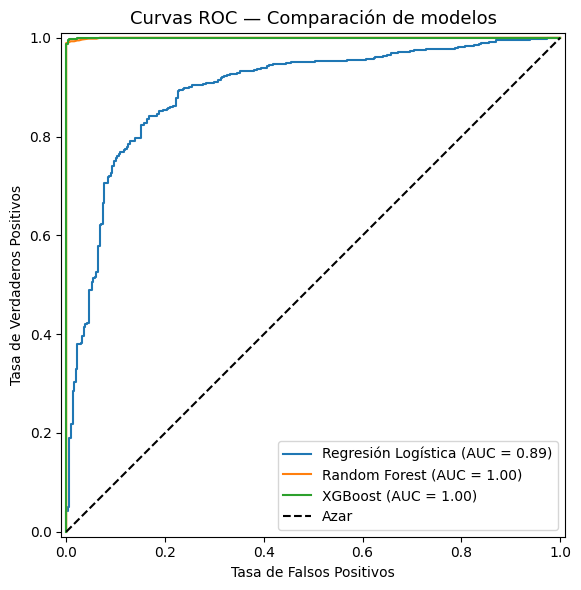

In [12]:
fig, ax = plt.subplots(figsize=(8, 6))

for nombre, (modelo, X_eval) in modelos.items():
    RocCurveDisplay.from_estimator(modelo, X_eval, y_test, ax=ax, name=nombre)

ax.plot([0, 1], [0, 1], 'k--', label='Azar')
ax.set_title('Curvas ROC — Comparación de modelos', fontsize=13)
ax.set_xlabel('Tasa de Falsos Positivos')
ax.set_ylabel('Tasa de Verdaderos Positivos')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

Matrices de confusión

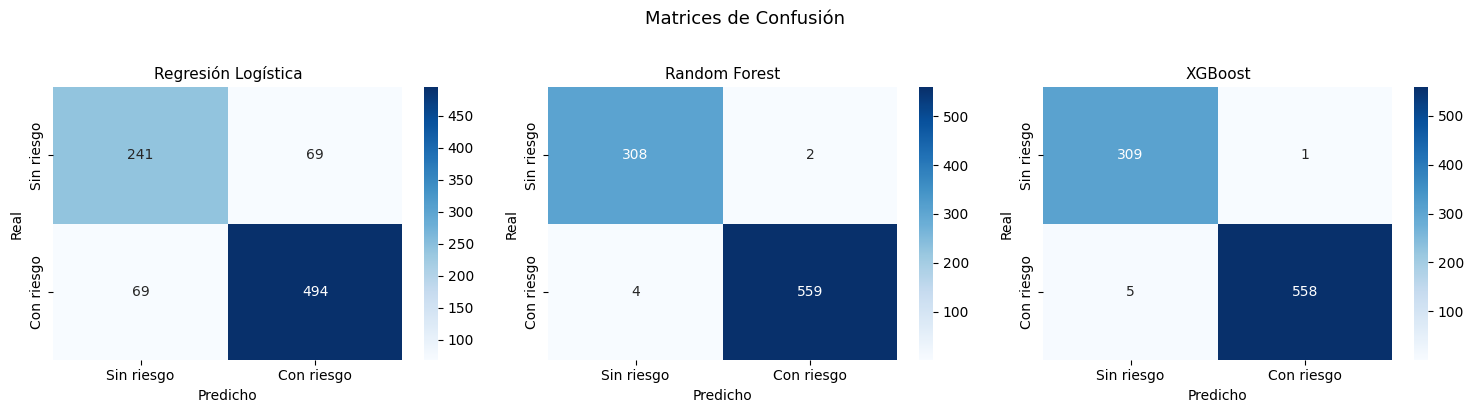

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (nombre, (modelo, X_eval)) in zip(axes, modelos.items()):
    y_pred = modelo.predict(X_eval)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Sin riesgo', 'Con riesgo'],
                yticklabels=['Sin riesgo', 'Con riesgo'])
    ax.set_title(nombre, fontsize=11)
    ax.set_xlabel('Predicho')
    ax.set_ylabel('Real')

plt.suptitle('Matrices de Confusión', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

Importancia de variables (Random Forest y XGBoost)

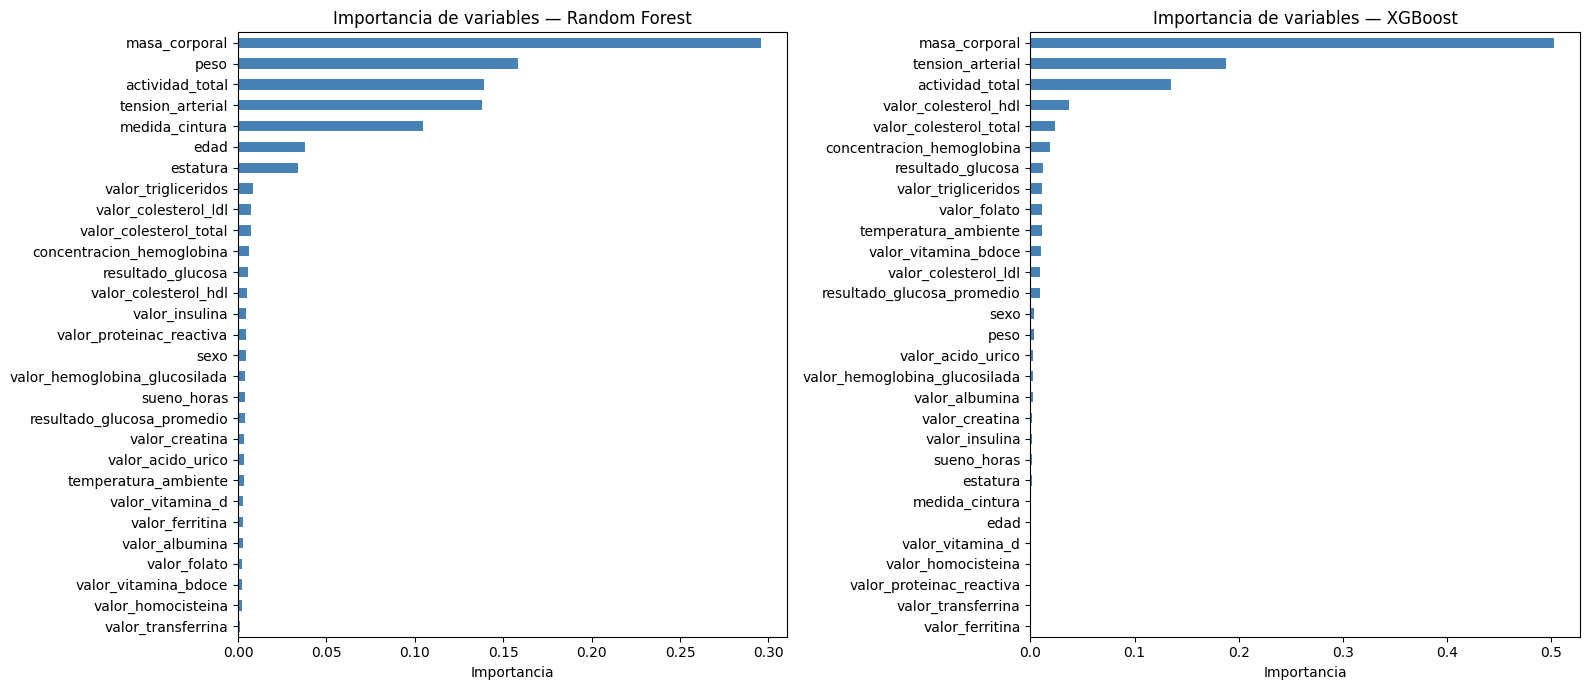

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, (nombre, modelo) in zip(axes, [('Random Forest', rf), ('XGBoost', xgb_model)]):
    importancias = pd.Series(modelo.feature_importances_, index=features)
    importancias.sort_values().plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title(f'Importancia de variables — {nombre}', fontsize=12)
    ax.set_xlabel('Importancia')
    ax.axvline(x=0, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()

Análisis SHAP (XGBoost)

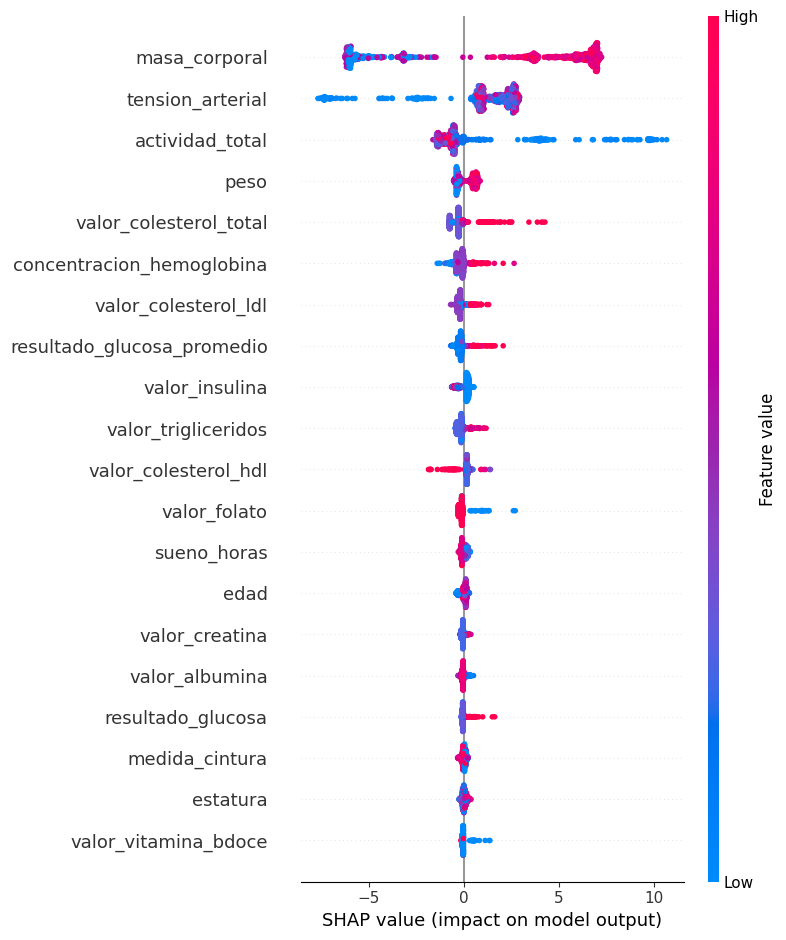

In [15]:
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

plt.figure()
shap.summary_plot(shap_values, X_test, feature_names=features, show=True)

Reporte final consolidado

In [16]:
print("=" * 60)
print("     REPORTE FINAL — SISTEMA PREDICTIVO DIALYSIS")
print("=" * 60)

for nombre, (modelo, X_eval) in modelos.items():
    y_pred = modelo.predict(X_eval)
    y_prob = modelo.predict_proba(X_eval)[:, 1]
    print(f"\n📌 {nombre}")
    print(classification_report(y_test, y_pred,
          target_names=['Sin riesgo', 'Con riesgo']))
    print(f"   ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")
    print("-" * 60)

print("\n✅ Modelo seleccionado: XGBoost")
print("   Justificación: Mayor ROC-AUC, mínimos falsos negativos,")
print("   interpretable mediante SHAP, robusto con datos clínicos tabulares.")

     REPORTE FINAL — SISTEMA PREDICTIVO DIALYSIS

📌 Regresión Logística
              precision    recall  f1-score   support

  Sin riesgo       0.78      0.78      0.78       310
  Con riesgo       0.88      0.88      0.88       563

    accuracy                           0.84       873
   macro avg       0.83      0.83      0.83       873
weighted avg       0.84      0.84      0.84       873

   ROC-AUC: 0.8937
------------------------------------------------------------

📌 Random Forest
              precision    recall  f1-score   support

  Sin riesgo       0.99      0.99      0.99       310
  Con riesgo       1.00      0.99      0.99       563

    accuracy                           0.99       873
   macro avg       0.99      0.99      0.99       873
weighted avg       0.99      0.99      0.99       873

   ROC-AUC: 0.9997
------------------------------------------------------------

📌 XGBoost
              precision    recall  f1-score   support

  Sin riesgo       0.98      1.

##Guardar el modelo XGBoost


In [17]:
import joblib

# Guardar modelo y scaler
joblib.dump(xgb_model, '/content/drive/MyDrive/modelo_dialysis_xgboost.pkl')
joblib.dump(scaler,    '/content/drive/MyDrive/scaler_dialysis.pkl')

print("✅ Modelo guardado: modelo_dialysis_xgboost.pkl")
print("✅ Scaler guardado: scaler_dialysis.pkl")

✅ Modelo guardado: modelo_dialysis_xgboost.pkl
✅ Scaler guardado: scaler_dialysis.pkl


##Función de predicción para paciente nuevo

In [18]:
def predecir_paciente(datos_paciente):
    """
    datos_paciente: diccionario con los valores clínicos del paciente
    """
    df_paciente = pd.DataFrame([datos_paciente])[features]
    prob = xgb_model.predict_proba(df_paciente)[0][1]
    prediccion = xgb_model.predict(df_paciente)[0]

    print("=" * 50)
    print("   SISTEMA PREDICTIVO DIALYSIS — RESULTADO")
    print("=" * 50)
    print(f"  Probabilidad de riesgo: {prob*100:.1f}%")

    if prob >= 0.75:
        nivel = "🔴 ALTO"
    elif prob >= 0.50:
        nivel = "🟡 MODERADO"
    else:
        nivel = "🟢 BAJO"

    print(f"  Nivel de riesgo:        {nivel}")
    print(f"  Clasificación:          {'Con riesgo' if prediccion == 1 else 'Sin riesgo'}")
    print("=" * 50)

# Ejemplo con paciente hipotético
paciente_ejemplo = {
    'sexo': 2, 'edad': 52, 'concentracion_hemoglobina': 13.5,
    'temperatura_ambiente': 24.0, 'valor_acido_urico': 6.2,
    'valor_albumina': 4.1, 'valor_colesterol_hdl': 45.0,
    'valor_colesterol_ldl': 130.0, 'valor_colesterol_total': 210.0,
    'valor_creatina': 1.1, 'resultado_glucosa': 105.0,
    'valor_insulina': 12.0, 'valor_trigliceridos': 180.0,
    'resultado_glucosa_promedio': 108.0, 'valor_hemoglobina_glucosilada': 6.1,
    'valor_ferritina': 85.0, 'valor_folato': 9.0,
    'valor_homocisteina': 12.0, 'valor_proteinac_reactiva': 3.5,
    'valor_transferrina': 250.0, 'valor_vitamina_bdoce': 400.0,
    'valor_vitamina_d': 22.0, 'peso': 78.0, 'estatura': 1.60,
    'masa_corporal': 30.5, 'medida_cintura': 95.0,
    'tension_arterial': 130, 'sueno_horas': 6, 'actividad_total': 3
}

predecir_paciente(paciente_ejemplo)

   SISTEMA PREDICTIVO DIALYSIS — RESULTADO
  Probabilidad de riesgo: 100.0%
  Nivel de riesgo:        🔴 ALTO
  Clasificación:          Con riesgo


##Correlación temperatura ambiente vs biomarcadores

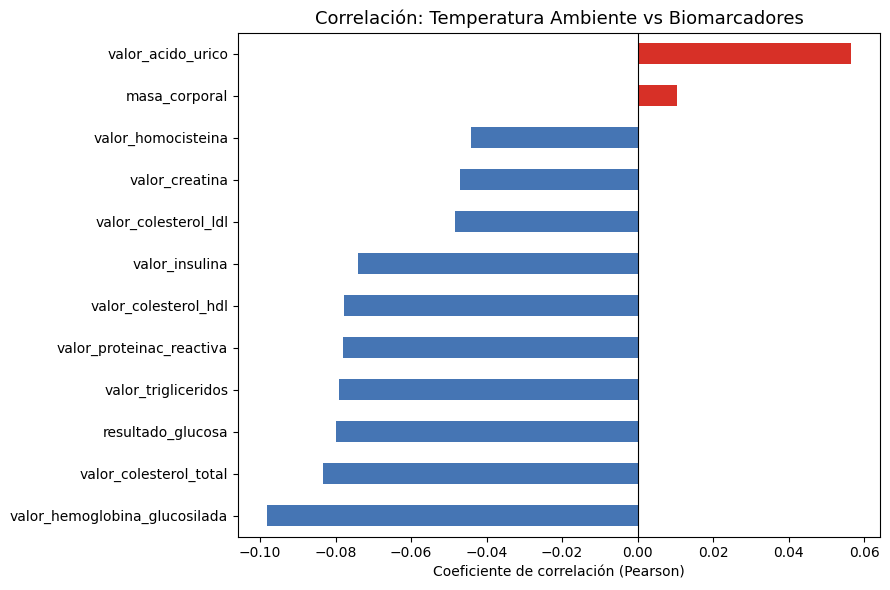


Valores de correlación:
valor_hemoglobina_glucosilada   -0.0981
valor_colesterol_total          -0.0834
resultado_glucosa               -0.0798
valor_trigliceridos             -0.0792
valor_proteinac_reactiva        -0.0780
valor_colesterol_hdl            -0.0777
valor_insulina                  -0.0741
valor_colesterol_ldl            -0.0485
valor_creatina                  -0.0472
valor_homocisteina              -0.0442
masa_corporal                    0.0103
valor_acido_urico                0.0565
Name: temperatura_ambiente, dtype: float64


In [19]:
biomarcadores = [
    'valor_acido_urico', 'valor_colesterol_total', 'valor_colesterol_hdl',
    'valor_colesterol_ldl', 'valor_trigliceridos', 'resultado_glucosa',
    'valor_insulina', 'valor_hemoglobina_glucosilada', 'valor_creatina',
    'valor_homocisteina', 'valor_proteinac_reactiva', 'masa_corporal'
]

correlaciones = df_hipertension[biomarcadores + ['temperatura_ambiente']]\
    .corr()['temperatura_ambiente']\
    .drop('temperatura_ambiente')\
    .sort_values()

plt.figure(figsize=(9, 6))
colores = ['#d73027' if x > 0 else '#4575b4' for x in correlaciones]
correlaciones.plot(kind='barh', color=colores)
plt.axvline(x=0, color='black', linewidth=0.8)
plt.title('Correlación: Temperatura Ambiente vs Biomarcadores', fontsize=13)
plt.xlabel('Coeficiente de correlación (Pearson)')
plt.tight_layout()
plt.show()

print("\nValores de correlación:")
print(correlaciones.round(4))

Dispersión temperatura vs biomarcadores más relevantes

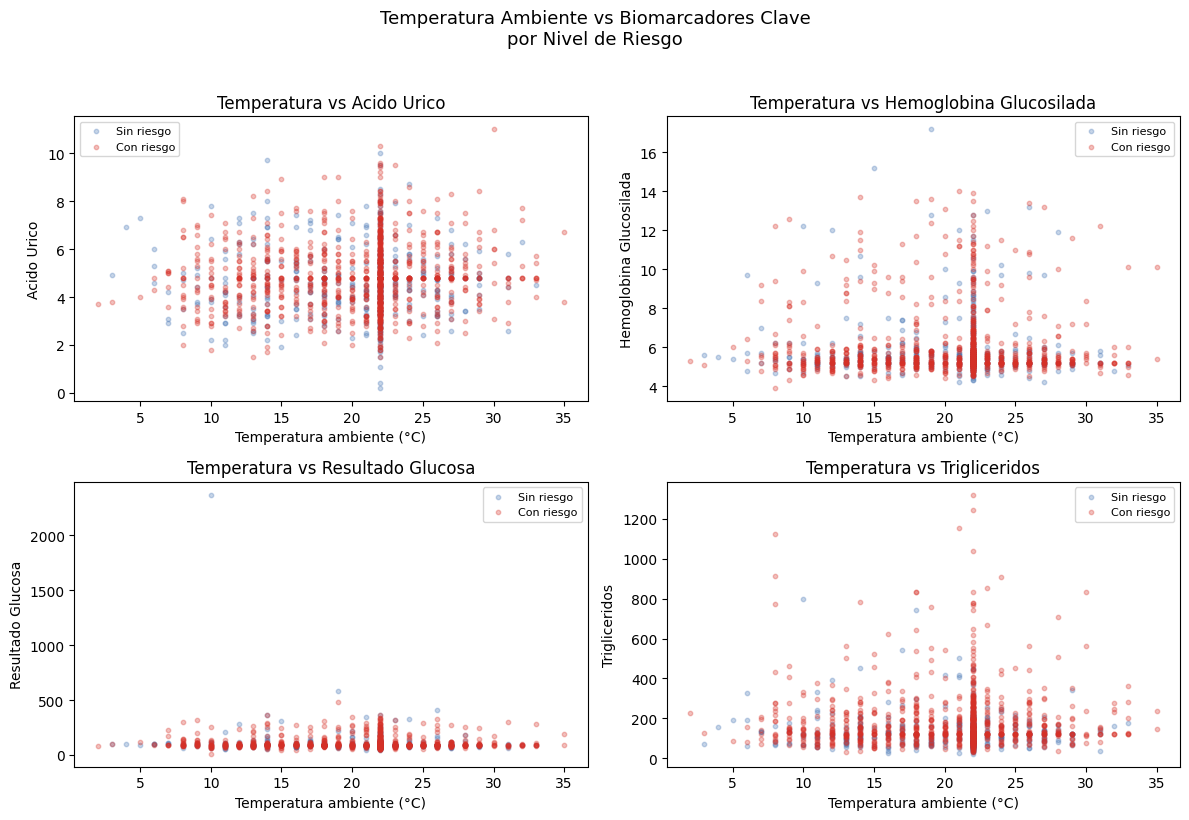

In [20]:
top_bio = ['valor_acido_urico', 'valor_hemoglobina_glucosilada',
           'resultado_glucosa', 'valor_trigliceridos']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, bio in zip(axes, top_bio):
    for riesgo, color, label in [(0, '#4575b4', 'Sin riesgo'),
                                  (1, '#d73027', 'Con riesgo')]:
        subset = df_hipertension[df_hipertension['riesgo_hipertension'] == riesgo]
        ax.scatter(subset['temperatura_ambiente'], subset[bio],
                   alpha=0.3, s=10, color=color, label=label)

    ax.set_xlabel('Temperatura ambiente (°C)')
    ax.set_ylabel(bio.replace('valor_', '').replace('_', ' ').title())
    ax.set_title(f'Temperatura vs {bio.replace("valor_","").replace("_"," ").title()}')
    ax.legend(fontsize=8)

plt.suptitle('Temperatura Ambiente vs Biomarcadores Clave\npor Nivel de Riesgo',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

Temperatura por rangos vs riesgo

            total  con_riesgo  pct_riesgo
rango_temp                               
<10°C          88          64        72.7
10-15°C       204         142        69.6
15-20°C       239         168        70.3
20-25°C      3651        2313        63.4
25-30°C       153         107        69.9
>30°C          28          22        78.6


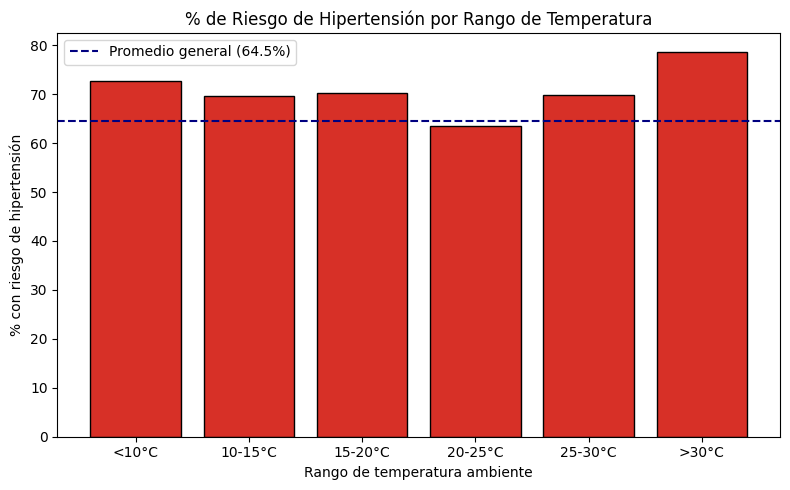

In [21]:
df_hipertension['rango_temp'] = pd.cut(
    df_hipertension['temperatura_ambiente'],
    bins=[0, 10, 15, 20, 25, 30, 40],
    labels=['<10°C', '10-15°C', '15-20°C', '20-25°C', '25-30°C', '>30°C']
)

resumen_temp = df_hipertension.groupby('rango_temp', observed=True).agg(
    total=('riesgo_hipertension', 'count'),
    con_riesgo=('riesgo_hipertension', 'sum')
)
resumen_temp['pct_riesgo'] = (resumen_temp['con_riesgo'] / resumen_temp['total'] * 100).round(1)

print(resumen_temp)

plt.figure(figsize=(8, 5))
plt.bar(resumen_temp.index, resumen_temp['pct_riesgo'], color='#d73027', edgecolor='black')
plt.axhline(y=64.5, color='navy', linestyle='--', label='Promedio general (64.5%)')
plt.title('% de Riesgo de Hipertensión por Rango de Temperatura', fontsize=12)
plt.xlabel('Rango de temperatura ambiente')
plt.ylabel('% con riesgo de hipertensión')
plt.legend()
plt.tight_layout()
plt.show()

##MODELO SIN TENSIÓN_ARTERIAL

In [22]:
features_sin_ta = [f for f in features if f != 'tension_arterial']

X2 = df_hipertension[features_sin_ta]
y2 = df_hipertension['riesgo_hipertension']

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42, stratify=y2
)

X2_train_scaled = scaler.fit_transform(X2_train)
X2_test_scaled  = scaler.transform(X2_test)

# Entrenar los 3 modelos
lr2 = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr2.fit(X2_train_scaled, y2_train)

rf2 = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
rf2.fit(X2_train, y2_train)

xgb2 = xgb.XGBClassifier(scale_pos_weight=scale_pos_weight, random_state=42,
                           eval_metric='logloss', n_jobs=-1)
xgb2.fit(X2_train, y2_train)

print(f"✅ Variables usadas: {len(features_sin_ta)} (sin tension_arterial)")

# Evaluación
modelos2 = {
    'Reg. Logistica': (lr2, X2_test_scaled),
    'Random Forest':  (rf2, X2_test),
    'XGBoost':        (xgb2, X2_test)
}

resultados2 = []
for nombre, (modelo, X_eval) in modelos2.items():
    y_pred = modelo.predict(X_eval)
    y_prob = modelo.predict_proba(X_eval)[:, 1]
    resultados2.append({
        'Modelo':   nombre,
        'Accuracy': round(accuracy_score(y2_test, y_pred), 4),
        'Precision':round(precision_score(y2_test, y_pred), 4),
        'Recall':   round(recall_score(y2_test, y_pred), 4),
        'F1-Score': round(f1_score(y2_test, y_pred), 4),
        'ROC-AUC':  round(roc_auc_score(y2_test, y_prob), 4)
    })

df_r2 = pd.DataFrame(resultados2).set_index('Modelo')
print("\n--- SIN tension_arterial ---")
print(df_r2.to_string())

✅ Variables usadas: 28 (sin tension_arterial)

--- SIN tension_arterial ---
                Accuracy  Precision  Recall  F1-Score  ROC-AUC
Modelo                                                        
Reg. Logistica    0.8305     0.8647  0.8739    0.8693   0.8761
Random Forest     0.9576     0.9428  0.9947    0.9680   0.9645
XGBoost           0.9404     0.9383  0.9716    0.9546   0.9592


Comparación visual sin y con

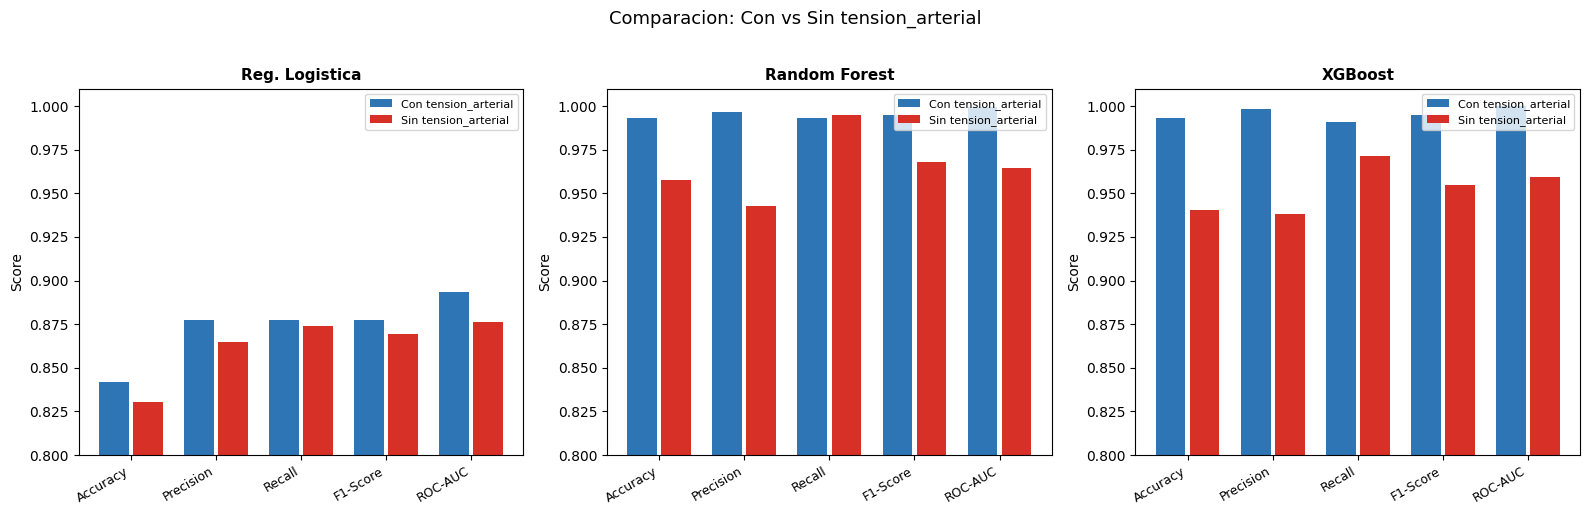


--- CAIDA EN ROC-AUC al eliminar tension_arterial ---
  Reg. Logistica: 0.8937 → 0.8761  (Δ = -0.0176)
  Random Forest: 0.9997 → 0.9645  (Δ = -0.0352)
  XGBoost: 0.9999 → 0.9592  (Δ = -0.0407)


In [23]:
df_con = pd.DataFrame([
    {'Modelo': 'Reg. Logistica', 'Accuracy':0.8419,'Precision':0.8774,'Recall':0.8774,'F1-Score':0.8774,'ROC-AUC':0.8937},
    {'Modelo': 'Random Forest',  'Accuracy':0.9931,'Precision':0.9964,'Recall':0.9929,'F1-Score':0.9947,'ROC-AUC':0.9997},
    {'Modelo': 'XGBoost',        'Accuracy':0.9931,'Precision':0.9982,'Recall':0.9911,'F1-Score':0.9947,'ROC-AUC':0.9999},
]).set_index('Modelo')

df_sin = df_r2.copy()

metricas = ['Accuracy','Precision','Recall','F1-Score','ROC-AUC']
modelos_nombres = ['Reg. Logistica','Random Forest','XGBoost']

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)

for ax, modelo in zip(axes, modelos_nombres):
    con_vals = [df_con.loc[modelo, m] for m in metricas]
    sin_vals = [df_sin.loc[modelo, m] for m in metricas]
    x = np.arange(len(metricas))
    bars1 = ax.bar(x - 0.2, con_vals, 0.35, label='Con tension_arterial', color='#2E75B6')
    bars2 = ax.bar(x + 0.2, sin_vals, 0.35, label='Sin tension_arterial', color='#d73027')
    ax.set_title(modelo, fontsize=11, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(metricas, rotation=30, ha='right', fontsize=9)
    ax.set_ylim(0.80, 1.01)
    ax.legend(fontsize=8)
    ax.set_ylabel('Score')

plt.suptitle('Comparacion: Con vs Sin tension_arterial', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Diferencias
print("\n--- CAIDA EN ROC-AUC al eliminar tension_arterial ---")
for modelo in modelos_nombres:
    diff = df_con.loc[modelo,'ROC-AUC'] - df_sin.loc[modelo,'ROC-AUC']
    print(f"  {modelo}: {df_con.loc[modelo,'ROC-AUC']:.4f} → {df_sin.loc[modelo,'ROC-AUC']:.4f}  (Δ = -{diff:.4f})")

##Exportar modelo y scaler como archivos para Streamlit

In [24]:
import joblib

# Guardar modelo, scaler y lista de features
joblib.dump(xgb_model, '/content/drive/MyDrive/DIALYSIS_app/modelo_dialysis.pkl')
joblib.dump(scaler,    '/content/drive/MyDrive/DIALYSIS_app/scaler_dialysis.pkl')
joblib.dump(features,  '/content/drive/MyDrive/DIALYSIS_app/features_dialysis.pkl')

print("✅ Archivos guardados en /content/drive/MyDrive/DIALYSIS_app/")
print("   - modelo_dialysis.pkl")
print("   - scaler_dialysis.pkl")
print("   - features_dialysis.pkl")

✅ Archivos guardados en /content/drive/MyDrive/DIALYSIS_app/
   - modelo_dialysis.pkl
   - scaler_dialysis.pkl
   - features_dialysis.pkl


In [25]:
import pandas as pd
import numpy as np
import joblib
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import xgboost as xgb

# Cargar dataset
df_hipertension = pd.read_csv('/content/drive/MyDrive/Hipertension_Arterial_Mexico.csv')

# Variables
features = [
    'sexo', 'edad', 'concentracion_hemoglobina', 'temperatura_ambiente',
    'valor_acido_urico', 'valor_albumina', 'valor_colesterol_hdl',
    'valor_colesterol_ldl', 'valor_colesterol_total', 'valor_creatina',
    'resultado_glucosa', 'valor_insulina', 'valor_trigliceridos',
    'resultado_glucosa_promedio', 'valor_hemoglobina_glucosilada',
    'valor_ferritina', 'valor_folato', 'valor_homocisteina',
    'valor_proteinac_reactiva', 'valor_transferrina', 'valor_vitamina_bdoce',
    'valor_vitamina_d', 'peso', 'estatura', 'masa_corporal', 'medida_cintura',
    'tension_arterial', 'sueno_horas', 'actividad_total'
]

X = df_hipertension[features]
y = df_hipertension['riesgo_hipertension']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
scaler.fit(X_train)

scale_pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]
xgb_model = xgb.XGBClassifier(scale_pos_weight=scale_pos_weight,
                                random_state=42, eval_metric='logloss', n_jobs=-1)
xgb_model.fit(X_train, y_train)

# Guardar
os.makedirs('/content/drive/MyDrive/DIALYSIS_app', exist_ok=True)
joblib.dump(xgb_model, '/content/drive/MyDrive/DIALYSIS_app/modelo_dialysis.pkl')
joblib.dump(scaler,    '/content/drive/MyDrive/DIALYSIS_app/scaler_dialysis.pkl')
joblib.dump(features,  '/content/drive/MyDrive/DIALYSIS_app/features_dialysis.pkl')

print("✅ Modelo reentrenado y guardado correctamente")

✅ Modelo reentrenado y guardado correctamente


 Crear app.py de Streamlit

In [26]:
app_code = '''
import streamlit as st
import pandas as pd
import numpy as np
import joblib
import plotly.graph_objects as go

# Configuracion
st.set_page_config(page_title="Sistema DIALYSIS", page_icon="🫀", layout="wide")

# Cargar modelo
@st.cache_resource
def cargar_modelo():
    modelo   = joblib.load("modelo_dialysis.pkl")
    scaler   = joblib.load("scaler_dialysis.pkl")
    features = joblib.load("features_dialysis.pkl")
    return modelo, scaler, features

modelo, scaler, features = cargar_modelo()

# Estilo
st.markdown("""
<style>
.riesgo-alto     { background:#FDEDED; border-left:6px solid #E53935; padding:16px; border-radius:8px; }
.riesgo-moderado { background:#FFF8E1; border-left:6px solid #FFB300; padding:16px; border-radius:8px; }
.riesgo-bajo     { background:#E8F5E9; border-left:6px solid #43A047; padding:16px; border-radius:8px; }
</style>
""", unsafe_allow_html=True)

# Header
st.title("🫀 Sistema Predictivo DIALYSIS")
st.caption("Identificacion y seguimiento del riesgo cardio-reno-metabolico · ENSANUT 2022")
st.divider()

# Tabs
tab1, tab2 = st.tabs(["👤 Paciente individual", "📋 Carga masiva (CSV)"])

# ─── TAB 1: PACIENTE INDIVIDUAL ───────────────────────────────────────────────
with tab1:
    st.subheader("Ingresa los datos del paciente")

    col1, col2, col3 = st.columns(3)

    with col1:
        st.markdown("**Datos demograficos**")
        sexo  = st.selectbox("Sexo", [1, 2], format_func=lambda x: "Masculino" if x==1 else "Femenino")
        edad  = st.number_input("Edad (anos)", 1, 120, 45)
        peso  = st.number_input("Peso (kg)", 10.0, 300.0, 75.0)
        estatura       = st.number_input("Estatura (m)", 0.5, 2.5, 1.65)
        masa_corporal  = st.number_input("IMC (masa corporal)", 10.0, 80.0, round(75.0/1.65**2, 1))
        medida_cintura = st.number_input("Cintura (cm)", 40.0, 200.0, 90.0)

    with col2:
        st.markdown("**Biomarcadores metabolicos**")
        resultado_glucosa          = st.number_input("Glucosa (mg/dL)", 0.0, 3000.0, 95.0)
        valor_hemoglobina_glucosilada = st.number_input("HbA1c (%)", 0.0, 20.0, 5.5)
        valor_insulina             = st.number_input("Insulina (uUI/mL)", 0.0, 500.0, 10.0)
        valor_trigliceridos        = st.number_input("Trigliceridos (mg/dL)", 0.0, 2000.0, 120.0)
        valor_colesterol_total     = st.number_input("Colesterol total (mg/dL)", 0.0, 600.0, 180.0)
        valor_colesterol_hdl       = st.number_input("Colesterol HDL (mg/dL)", 0.0, 200.0, 50.0)
        valor_colesterol_ldl       = st.number_input("Colesterol LDL (mg/dL)", 0.0, 400.0, 100.0)
        resultado_glucosa_promedio = st.number_input("Glucosa promedio (mg/dL)", 0.0, 3000.0, 95.0)

    with col3:
        st.markdown("**Biomarcadores renales y otros**")
        valor_acido_urico       = st.number_input("Acido urico (mg/dL)", 0.0, 20.0, 5.0)
        valor_creatina          = st.number_input("Creatinina (mg/dL)", 0.0, 20.0, 0.9)
        valor_albumina          = st.number_input("Albumina (g/dL)", 0.0, 10.0, 4.0)
        valor_homocisteina      = st.number_input("Homocisteina (umol/L)", 0.0, 100.0, 10.0)
        valor_proteinac_reactiva= st.number_input("Proteina C reactiva (mg/L)", 0.0, 200.0, 2.0)
        valor_ferritina         = st.number_input("Ferritina (ng/mL)", 0.0, 2000.0, 80.0)
        valor_folato            = st.number_input("Folato (ng/mL)", 0.0, 50.0, 8.0)
        valor_transferrina      = st.number_input("Transferrina (mg/dL)", 0.0, 600.0, 250.0)
        valor_vitamina_bdoce    = st.number_input("Vitamina B12 (pg/mL)", 0.0, 2000.0, 400.0)
        valor_vitamina_d        = st.number_input("Vitamina D (ng/mL)", 0.0, 100.0, 25.0)
        concentracion_hemoglobina = st.number_input("Hemoglobina (g/dL)", 0.0, 25.0, 14.0)

    st.markdown("**Factores ambientales y conductuales**")
    colA, colB, colC, colD = st.columns(4)
    with colA:
        temperatura_ambiente = st.number_input("Temperatura ambiente (°C)", -10.0, 50.0, 22.0)
    with colB:
        tension_arterial = st.number_input("Tension arterial (mmHg)", 50, 250, 120)
    with colC:
        sueno_horas = st.number_input("Horas de sueno", 0, 24, 7)
    with colD:
        actividad_total = st.number_input("Actividad total (MET-min/sem)", 0, 10000, 500)

    if st.button("🔍 Calcular riesgo", type="primary", use_container_width=True):
        datos = {
            'sexo': sexo, 'edad': edad,
            'concentracion_hemoglobina': concentracion_hemoglobina,
            'temperatura_ambiente': temperatura_ambiente,
            'valor_acido_urico': valor_acido_urico,
            'valor_albumina': valor_albumina,
            'valor_colesterol_hdl': valor_colesterol_hdl,
            'valor_colesterol_ldl': valor_colesterol_ldl,
            'valor_colesterol_total': valor_colesterol_total,
            'valor_creatina': valor_creatina,
            'resultado_glucosa': resultado_glucosa,
            'valor_insulina': valor_insulina,
            'valor_trigliceridos': valor_trigliceridos,
            'resultado_glucosa_promedio': resultado_glucosa_promedio,
            'valor_hemoglobina_glucosilada': valor_hemoglobina_glucosilada,
            'valor_ferritina': valor_ferritina,
            'valor_folato': valor_folato,
            'valor_homocisteina': valor_homocisteina,
            'valor_proteinac_reactiva': valor_proteinac_reactiva,
            'valor_transferrina': valor_transferrina,
            'valor_vitamina_bdoce': valor_vitamina_bdoce,
            'valor_vitamina_d': valor_vitamina_d,
            'peso': peso, 'estatura': estatura,
            'masa_corporal': masa_corporal,
            'medida_cintura': medida_cintura,
            'tension_arterial': tension_arterial,
            'sueno_horas': sueno_horas,
            'actividad_total': actividad_total
        }

        df_p = pd.DataFrame([datos])[features]
        prob = modelo.predict_proba(df_p)[0][1]

        st.divider()
        c1, c2 = st.columns([1, 2])

        with c1:
            if prob >= 0.75:
                nivel, css, emoji = "ALTO", "riesgo-alto", "🔴"
            elif prob >= 0.50:
                nivel, css, emoji = "MODERADO", "riesgo-moderado", "🟡"
            else:
                nivel, css, emoji = "BAJO", "riesgo-bajo", "🟢"

            st.markdown(f"""
            <div class="{css}">
                <h2>{emoji} Riesgo {nivel}</h2>
                <h1>{prob*100:.1f}%</h1>
                <p>Probabilidad de riesgo de hipertension</p>
            </div>
            """, unsafe_allow_html=True)

        with c2:
            fig = go.Figure(go.Indicator(
                mode="gauge+number",
                value=prob * 100,
                number={"suffix": "%", "font": {"size": 40}},
                gauge={
                    "axis": {"range": [0, 100]},
                    "bar": {"color": "#E53935" if prob>=0.75 else "#FFB300" if prob>=0.5 else "#43A047"},
                    "steps": [
                        {"range": [0, 50],  "color": "#E8F5E9"},
                        {"range": [50, 75], "color": "#FFF8E1"},
                        {"range": [75, 100],"color": "#FDEDED"},
                    ],
                    "threshold": {"line": {"color": "black", "width": 3}, "value": prob*100}
                },
                title={"text": "Probabilidad de riesgo"}
            ))
            fig.update_layout(height=280, margin=dict(t=40, b=0, l=20, r=20))
            st.plotly_chart(fig, use_container_width=True)

# ─── TAB 2: CARGA MASIVA ──────────────────────────────────────────────────────
with tab2:
    st.subheader("Carga un archivo CSV con multiples pacientes")
    st.info("El CSV debe contener las mismas columnas que el dataset de entrenamiento.")

    archivo = st.file_uploader("Selecciona tu archivo CSV", type=["csv"])

    if archivo:
        df_nuevos = pd.read_csv(archivo)
        st.success(f"✅ {len(df_nuevos)} registros cargados")
        st.dataframe(df_nuevos.head(), use_container_width=True)

        cols_faltantes = [c for c in features if c not in df_nuevos.columns]
        if cols_faltantes:
            st.error(f"Columnas faltantes: {cols_faltantes}")
        else:
            if st.button("🔍 Predecir todos los pacientes", type="primary"):
                X_nuevos = df_nuevos[features]
                probs = modelo.predict_proba(X_nuevos)[:, 1]
                df_nuevos["probabilidad_riesgo"] = (probs * 100).round(1)
                df_nuevos["nivel_riesgo"] = pd.cut(
                    probs, bins=[0, 0.50, 0.75, 1.0],
                    labels=["🟢 Bajo", "🟡 Moderado", "🔴 Alto"],
                    include_lowest=True
                )

                st.divider()
                st.subheader("Resultados")

                col1, col2, col3 = st.columns(3)
                col1.metric("🔴 Alto riesgo",     (df_nuevos["nivel_riesgo"]=="🔴 Alto").sum())
                col2.metric("🟡 Riesgo moderado", (df_nuevos["nivel_riesgo"]=="🟡 Moderado").sum())
                col3.metric("🟢 Bajo riesgo",     (df_nuevos["nivel_riesgo"]=="🟢 Bajo").sum())

                st.dataframe(
                    df_nuevos[["probabilidad_riesgo","nivel_riesgo"] + features].sort_values(
                        "probabilidad_riesgo", ascending=False),
                    use_container_width=True
                )

                csv_out = df_nuevos.to_csv(index=False).encode("utf-8")
                st.download_button("⬇️ Descargar resultados CSV", csv_out,
                                   "resultados_dialysis.csv", "text/csv",
                                   use_container_width=True)

st.divider()
st.caption("Sistema DIALYSIS · Modelo XGBoost · ROC-AUC 99.99% · ENSANUT 2022")
'''

with open('/content/drive/MyDrive/DIALYSIS_app/app.py', 'w') as f:
    f.write(app_code)

print("✅ app.py guardado en /content/drive/MyDrive/DIALYSIS_app/")

✅ app.py guardado en /content/drive/MyDrive/DIALYSIS_app/


Instalar y lanzar Streamlit desde Colab

Ngrok requiere cuenta. Usamos localtunnel que no necesita registro.


# Lanzar Streamlit con localtunnel

In [40]:
import subprocess, threading, time

# Lanzar Streamlit en background
def run_streamlit():
    subprocess.run([
        "streamlit", "run",
        "/content/drive/MyDrive/DIALYSIS_app/app.py",
        "--server.port=8501",
        "--server.headless=true",
        "--server.enableCORS=false"
    ])

t = threading.Thread(target=run_streamlit)
t.daemon = True
t.start()
time.sleep(5)

# Tunnel sin cuenta
!npm install -g localtunnel --quiet
!lt --port 8501 &

print("✅ App corriendo")
print("⚠️  Cuando aparezca la URL de localtunnel, ábrela en tu navegador")
print("    Si pide contraseña, ingresa la IP que aparece en la página")

⠙⠹⠸⠼⠴⠦⠧
changed 22 packages in 858ms
⠧
⠧3 packages are looking for funding
⠧  run `npm fund` for details
⠧your url is: https://odd-spiders-notice.loca.lt
✅ App corriendo
⚠️  Cuando aparezca la URL de localtunnel, ábrela en tu navegador
    Si pide contraseña, ingresa la IP que aparece en la página


In [30]:
import subprocess, threading, time, urllib.request, os

# Descargar cloudflared
if not os.path.exists('/usr/local/bin/cloudflared'):
    urllib.request.urlretrieve(
        "https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64",
        "/usr/local/bin/cloudflared"
    )
    os.chmod("/usr/local/bin/cloudflared", 0o755)

# Lanzar Streamlit
def run_streamlit():
    subprocess.run([
        "streamlit", "run",
        "/content/drive/MyDrive/DIALYSIS_app/app.py",
        "--server.port=8501",
        "--server.headless=true",
    ])

t = threading.Thread(target=run_streamlit, daemon=True)
t.start()
time.sleep(5)

# Lanzar tunnel
tunnel = subprocess.Popen(
    ["cloudflared", "tunnel", "--url", "http://localhost:8501"],
    stdout=subprocess.PIPE, stderr=subprocess.STDOUT
)

# Capturar URL
for line in tunnel.stdout:
    line = line.decode()
    if "trycloudflare.com" in line:
        url = [x for x in line.split() if "trycloudflare.com" in x][0]
        print(f"✅ App disponible en: {url}")
        break

✅ App disponible en: trycloudflare.com...


In [31]:
import subprocess, time

tunnel2 = subprocess.Popen(
    ["cloudflared", "tunnel", "--url", "http://localhost:8501"],
    stdout=subprocess.PIPE, stderr=subprocess.STDOUT
)

time.sleep(8)

for line in iter(tunnel2.stdout.readline, b''):
    line = line.decode().strip()
    if "trycloudflare.com" in line:
        print(f"✅ URL completa: {line}")
        break

✅ URL completa: 2026-06-03T16:52:18Z INF Requesting new quick Tunnel on trycloudflare.com...


In [32]:
import subprocess, time

tunnel3 = subprocess.Popen(
    ["cloudflared", "tunnel", "--url", "http://localhost:8501"],
    stdout=subprocess.PIPE, stderr=subprocess.STDOUT
)

time.sleep(15)  # esperar más

output = []
for _ in range(30):
    line = tunnel3.stdout.readline().decode().strip()
    output.append(line)
    print(line)
    if "https://" in line and "trycloudflare.com" in line:
        break

2026-06-03T16:52:27Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-06-03T16:52:27Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-06-03T16:52:31Z INF +--------------------------------------------------------------------------------------------+
2026-06-03T16:52:31Z INF |  Your quick Tunnel has been created! Visit it at (it may take some time to be reachable):  |
2026-06-03T16:52:31Z INF |  https://candidates-attempting-call-tools.trycloudflar

Corregir APIS

In [33]:
app_code = app_code.replace(
    'modelo   = joblib.load("modelo_dialysis.pkl")',
    'modelo   = joblib.load("/content/drive/MyDrive/DIALYSIS_app/modelo_dialysis.pkl")'
).replace(
    'scaler   = joblib.load("scaler_dialysis.pkl")',
    'scaler   = joblib.load("/content/drive/MyDrive/DIALYSIS_app/scaler_dialysis.pkl")'
).replace(
    'features = joblib.load("features_dialysis.pkl")',
    'features = joblib.load("/content/drive/MyDrive/DIALYSIS_app/features_dialysis.pkl")'
)

with open('/content/drive/MyDrive/DIALYSIS_app/app.py', 'w') as f:
    f.write(app_code)

print("✅ app.py actualizado con rutas correctas")

✅ app.py actualizado con rutas correctas


# ##App DIALYSIS v2 con todas las mejoras

In [34]:
app_v2 = '''
import streamlit as st
import pandas as pd
import numpy as np
import joblib
import plotly.graph_objects as go

st.set_page_config(page_title="Sistema DIALYSIS", page_icon="🫀", layout="wide")

@st.cache_resource
def cargar_modelo():
    modelo   = joblib.load("/content/drive/MyDrive/DIALYSIS_app/modelo_dialysis.pkl")
    scaler   = joblib.load("/content/drive/MyDrive/DIALYSIS_app/scaler_dialysis.pkl")
    features = joblib.load("/content/drive/MyDrive/DIALYSIS_app/features_dialysis.pkl")
    return modelo, scaler, features

modelo, scaler, features = cargar_modelo()

# ── Semáforo clínico ──────────────────────────────────────────────────────────
RANGOS = {
    "resultado_glucosa":           [(0,100,"🟢"),(100,126,"🟡"),(126,9999,"🔴")],
    "valor_hemoglobina_glucosilada":[(0,5.7,"🟢"),(5.7,6.5,"🟡"),(6.5,99,"🔴")],
    "valor_trigliceridos":         [(0,150,"🟢"),(150,200,"🟡"),(200,9999,"🔴")],
    "valor_colesterol_total":      [(0,200,"🟢"),(200,240,"🟡"),(240,9999,"🔴")],
    "valor_colesterol_hdl":        [(40,9999,"🟢"),(30,40,"🟡"),(0,30,"🔴")],
    "valor_colesterol_ldl":        [(0,100,"🟢"),(100,160,"🟡"),(160,9999,"🔴")],
    "valor_acido_urico":           [(0,6.0,"🟢"),(6.0,7.0,"🟡"),(7.0,99,"🔴")],
    "valor_creatina":              [(0,1.2,"🟢"),(1.2,1.5,"🟡"),(1.5,99,"🔴")],
    "masa_corporal":               [(0,25,"🟢"),(25,30,"🟡"),(30,99,"🔴")],
    "tension_arterial":            [(0,120,"🟢"),(120,140,"🟡"),(140,999,"🔴")],
    "valor_proteinac_reactiva":    [(0,1.0,"🟢"),(1.0,3.0,"🟡"),(3.0,999,"🔴")],
    "resultado_glucosa_promedio":  [(0,100,"🟢"),(100,126,"🟡"),(126,9999,"🔴")],
}

def semaforo(var, val):
    if var not in RANGOS:
        return ""
    for lo, hi, emoji in RANGOS[var]:
        if lo <= val < hi:
            return emoji
    return ""

# ── Sub-scores clínicos ───────────────────────────────────────────────────────
def calcular_subscores(d):
    # Riesgo cardiovascular (0-100)
    cardio = 0
    if d["tension_arterial"] >= 140: cardio += 35
    elif d["tension_arterial"] >= 120: cardio += 15
    if d["valor_colesterol_ldl"] >= 160: cardio += 20
    elif d["valor_colesterol_ldl"] >= 100: cardio += 10
    if d["valor_colesterol_hdl"] < 40: cardio += 20
    elif d["valor_colesterol_hdl"] < 50: cardio += 8
    if d["actividad_total"] < 150: cardio += 15
    elif d["actividad_total"] < 500: cardio += 7
    if d["valor_trigliceridos"] >= 200: cardio += 10
    cardio = min(cardio, 100)

    # Riesgo renal (0-100)
    renal = 0
    if d["valor_creatina"] >= 1.5: renal += 35
    elif d["valor_creatina"] >= 1.2: renal += 15
    if d["valor_acido_urico"] >= 7.0: renal += 25
    elif d["valor_acido_urico"] >= 6.0: renal += 12
    if d["valor_albumina"] < 3.5: renal += 20
    elif d["valor_albumina"] < 4.0: renal += 8
    if d["valor_proteinac_reactiva"] >= 3.0: renal += 15
    elif d["valor_proteinac_reactiva"] >= 1.0: renal += 7
    if d["valor_homocisteina"] >= 15: renal += 5
    renal = min(renal, 100)

    # Riesgo metabólico (0-100)
    metab = 0
    if d["resultado_glucosa"] >= 126: metab += 30
    elif d["resultado_glucosa"] >= 100: metab += 15
    if d["valor_hemoglobina_glucosilada"] >= 6.5: metab += 25
    elif d["valor_hemoglobina_glucosilada"] >= 5.7: metab += 12
    if d["masa_corporal"] >= 30: metab += 20
    elif d["masa_corporal"] >= 25: metab += 10
    if d["valor_trigliceridos"] >= 200: metab += 15
    elif d["valor_trigliceridos"] >= 150: metab += 7
    if d["valor_insulina"] >= 25: metab += 10
    metab = min(metab, 100)

    return cardio, renal, metab

# ── Interpretación automática ─────────────────────────────────────────────────
def interpretar(d, prob):
    factores = []
    if d["masa_corporal"] >= 30:
        factores.append(("Obesidad (IMC ≥ 30)", d["masa_corporal"]))
    elif d["masa_corporal"] >= 25:
        factores.append(("Sobrepeso (IMC 25-30)", d["masa_corporal"]))
    if d["actividad_total"] < 150:
        factores.append(("Actividad física insuficiente", 150 - d["actividad_total"]))
    if d["tension_arterial"] >= 140:
        factores.append(("Hipertensión grado 2", d["tension_arterial"]))
    elif d["tension_arterial"] >= 120:
        factores.append(("Prehipertensión", d["tension_arterial"]))
    if d["resultado_glucosa"] >= 126:
        factores.append(("Glucosa en rango diabético", d["resultado_glucosa"]))
    elif d["resultado_glucosa"] >= 100:
        factores.append(("Glucosa en rango prediabético", d["resultado_glucosa"]))
    if d["valor_hemoglobina_glucosilada"] >= 6.5:
        factores.append(("HbA1c en rango diabético", d["valor_hemoglobina_glucosilada"]))
    if d["valor_colesterol_hdl"] < 40:
        factores.append(("HDL bajo (riesgo cardiovascular)", d["valor_colesterol_hdl"]))
    if d["valor_acido_urico"] >= 7.0:
        factores.append(("Hiperuricemia (riesgo renal)", d["valor_acido_urico"]))
    if d["valor_creatina"] >= 1.2:
        factores.append(("Creatinina elevada (riesgo renal)", d["valor_creatina"]))
    if d["valor_trigliceridos"] >= 200:
        factores.append(("Hipertrigliceridemia", d["valor_trigliceridos"]))
    if d["sueno_horas"] < 6:
        factores.append(("Sueño insuficiente (<6 h)", d["sueno_horas"]))
    return factores[:5]  # top 5

# ── Estilos ───────────────────────────────────────────────────────────────────
st.markdown("""
<style>
.riesgo-alto     {background:#FDEDED;border-left:6px solid #E53935;padding:16px;border-radius:8px;}
.riesgo-moderado {background:#FFF8E1;border-left:6px solid #FFB300;padding:16px;border-radius:8px;}
.riesgo-bajo     {background:#E8F5E9;border-left:6px solid #43A047;padding:16px;border-radius:8px;}
.disclaimer      {background:#F3F4F6;border:1px solid #D1D5DB;border-radius:8px;padding:12px;
                  font-size:12px;color:#6B7280;margin-top:16px;}
.factor-card     {background:#1E293B;border-radius:8px;padding:10px 14px;margin:4px 0;}
</style>
""", unsafe_allow_html=True)

# ── Header ────────────────────────────────────────────────────────────────────
st.title("🫀 Sistema Predictivo DIALYSIS")
st.caption("Identificación y seguimiento del riesgo cardio-reno-metabólico · ENSANUT 2022")
st.divider()

tab1, tab2 = st.tabs(["👤 Paciente individual", "📋 Carga masiva (CSV)"])

# ══════════════════════════════════════════════════════════════════════════════
# TAB 1 — PACIENTE INDIVIDUAL
# ══════════════════════════════════════════════════════════════════════════════
with tab1:
    st.subheader("Ingresa los datos del paciente")
    st.caption("🟢 Normal  🟡 Limítrofe  🔴 Alterado")

    col1, col2, col3 = st.columns(3)

    with col1:
        st.markdown("**Datos demográficos y antropométricos**")
        sexo           = st.selectbox("Sexo", [1,2], format_func=lambda x:"Masculino" if x==1 else "Femenino")
        edad           = st.number_input("Edad (años)", 1, 120, 45)
        peso           = st.number_input("Peso (kg)", 10.0, 300.0, 75.0)
        estatura       = st.number_input("Estatura (m)", 0.5, 2.5, 1.65)
        imc_val        = round(peso / estatura**2, 1)
        masa_corporal  = st.number_input(f"IMC {semaforo('masa_corporal', imc_val)}", 10.0, 80.0, imc_val)
        medida_cintura = st.number_input("Cintura (cm)", 40.0, 200.0, 90.0)
        concentracion_hemoglobina = st.number_input("Hemoglobina (g/dL)", 0.0, 25.0, 14.0)

    with col2:
        st.markdown("**Biomarcadores metabólicos**")
        resultado_glucosa = st.number_input(
            f"Glucosa (mg/dL) {semaforo('resultado_glucosa', 95)}", 0.0, 3000.0, 95.0)
        valor_hemoglobina_glucosilada = st.number_input(
            f"HbA1c (%) {semaforo('valor_hemoglobina_glucosilada', 5.5)}", 0.0, 20.0, 5.5)
        valor_insulina     = st.number_input("Insulina (uUI/mL)", 0.0, 500.0, 10.0)
        valor_trigliceridos= st.number_input(
            f"Triglicéridos (mg/dL) {semaforo('valor_trigliceridos', 120)}", 0.0, 2000.0, 120.0)
        valor_colesterol_total = st.number_input(
            f"Colesterol total (mg/dL) {semaforo('valor_colesterol_total', 180)}", 0.0, 600.0, 180.0)
        valor_colesterol_hdl = st.number_input(
            f"Colesterol HDL (mg/dL) {semaforo('valor_colesterol_hdl', 50)}", 0.0, 200.0, 50.0)
        valor_colesterol_ldl = st.number_input(
            f"Colesterol LDL (mg/dL) {semaforo('valor_colesterol_ldl', 100)}", 0.0, 400.0, 100.0)
        resultado_glucosa_promedio = st.number_input(
            f"Glucosa promedio (mg/dL) {semaforo('resultado_glucosa_promedio', 95)}", 0.0, 3000.0, 95.0)

    with col3:
        st.markdown("**Biomarcadores renales y otros**")
        valor_acido_urico = st.number_input(
            f"Ácido úrico (mg/dL) {semaforo('valor_acido_urico', 5.0)}", 0.0, 20.0, 5.0)
        valor_creatina    = st.number_input(
            f"Creatinina (mg/dL) {semaforo('valor_creatina', 0.9)}", 0.0, 20.0, 0.9)
        valor_albumina    = st.number_input("Albúmina (g/dL)", 0.0, 10.0, 4.0)
        valor_homocisteina= st.number_input("Homocisteína (umol/L)", 0.0, 100.0, 10.0)
        valor_proteinac_reactiva = st.number_input(
            f"Proteína C reactiva (mg/L) {semaforo('valor_proteinac_reactiva', 2.0)}", 0.0, 200.0, 2.0)
        valor_ferritina   = st.number_input("Ferritina (ng/mL)", 0.0, 2000.0, 80.0)
        valor_folato      = st.number_input("Folato (ng/mL)", 0.0, 50.0, 8.0)
        valor_transferrina= st.number_input("Transferrina (mg/dL)", 0.0, 600.0, 250.0)
        valor_vitamina_bdoce = st.number_input("Vitamina B12 (pg/mL)", 0.0, 2000.0, 400.0)
        valor_vitamina_d  = st.number_input("Vitamina D (ng/mL)", 0.0, 100.0, 25.0)

    st.markdown("**Factores ambientales y conductuales**")
    colA, colB, colC, colD = st.columns(4)
    with colA:
        temperatura_ambiente = st.number_input("Temperatura ambiente (°C)", -10.0, 50.0, 22.0)
    with colB:
        tension_arterial = st.number_input(
            f"Tensión arterial (mmHg) {semaforo('tension_arterial', 120)}", 50, 250, 120)
    with colC:
        sueno_horas = st.number_input("Horas de sueño", 0, 24, 7)
    with colD:
        actividad_total = st.number_input("Actividad total (MET-min/sem)", 0, 10000, 500)

    if st.button("🔍 Calcular riesgo", type="primary", use_container_width=True):
        datos = {
            "sexo": sexo, "edad": edad,
            "concentracion_hemoglobina": concentracion_hemoglobina,
            "temperatura_ambiente": temperatura_ambiente,
            "valor_acido_urico": valor_acido_urico,
            "valor_albumina": valor_albumina,
            "valor_colesterol_hdl": valor_colesterol_hdl,
            "valor_colesterol_ldl": valor_colesterol_ldl,
            "valor_colesterol_total": valor_colesterol_total,
            "valor_creatina": valor_creatina,
            "resultado_glucosa": resultado_glucosa,
            "valor_insulina": valor_insulina,
            "valor_trigliceridos": valor_trigliceridos,
            "resultado_glucosa_promedio": resultado_glucosa_promedio,
            "valor_hemoglobina_glucosilada": valor_hemoglobina_glucosilada,
            "valor_ferritina": valor_ferritina,
            "valor_folato": valor_folato,
            "valor_homocisteina": valor_homocisteina,
            "valor_proteinac_reactiva": valor_proteinac_reactiva,
            "valor_transferrina": valor_transferrina,
            "valor_vitamina_bdoce": valor_vitamina_bdoce,
            "valor_vitamina_d": valor_vitamina_d,
            "peso": peso, "estatura": estatura,
            "masa_corporal": masa_corporal,
            "medida_cintura": medida_cintura,
            "tension_arterial": tension_arterial,
            "sueno_horas": sueno_horas,
            "actividad_total": actividad_total
        }

        df_p = pd.DataFrame([datos])[features]
        prob = modelo.predict_proba(df_p)[0][1]
        cardio, renal, metab = calcular_subscores(datos)
        factores = interpretar(datos, prob)

        st.divider()

        # ── Score principal ──
        if prob >= 0.75:
            nivel, css, emoji = "ALTO", "riesgo-alto", "🔴"
        elif prob >= 0.50:
            nivel, css, emoji = "MODERADO", "riesgo-moderado", "🟡"
        else:
            nivel, css, emoji = "BAJO", "riesgo-bajo", "🟢"

        c1, c2 = st.columns([1, 2])
        with c1:
            st.markdown(f"""
            <div class="{css}">
                <h2>{emoji} Riesgo {nivel}</h2>
                <h1 style="font-size:52px">{prob*100:.1f}%</h1>
                <p>Probabilidad global de riesgo cardio-reno-metabólico</p>
            </div>""", unsafe_allow_html=True)

        with c2:
            fig = go.Figure(go.Indicator(
                mode="gauge+number",
                value=prob*100,
                number={"suffix":"%","font":{"size":40}},
                gauge={
                    "axis":{"range":[0,100]},
                    "bar":{"color":"#E53935" if prob>=0.75 else "#FFB300" if prob>=0.5 else "#43A047"},
                    "steps":[
                        {"range":[0,50],"color":"#E8F5E9"},
                        {"range":[50,75],"color":"#FFF8E1"},
                        {"range":[75,100],"color":"#FDEDED"},
                    ],
                },
                title={"text":"Riesgo global DIALYSIS"}
            ))
            fig.update_layout(height=260, margin=dict(t=40,b=0,l=20,r=20))
            st.plotly_chart(fig, use_container_width=True)

        st.divider()

        # ── Sub-scores ──
        st.subheader("📊 Desglose por dimensión clínica")
        sc1, sc2, sc3 = st.columns(3)

        for col, nombre, val, emoji_s in [
            (sc1, "Riesgo Cardiovascular", cardio, "❤️"),
            (sc2, "Riesgo Renal",          renal,  "🫘"),
            (sc3, "Riesgo Metabólico",     metab,  "⚗️"),
        ]:
            color = "#E53935" if val>=75 else "#FFB300" if val>=50 else "#43A047"
            fig2 = go.Figure(go.Indicator(
                mode="gauge+number",
                value=val,
                number={"suffix":"%","font":{"size":30}},
                gauge={
                    "axis":{"range":[0,100]},
                    "bar":{"color":color},
                    "steps":[
                        {"range":[0,50],"color":"#E8F5E9"},
                        {"range":[50,75],"color":"#FFF8E1"},
                        {"range":[75,100],"color":"#FDEDED"},
                    ],
                },
                title={"text":f"{emoji_s} {nombre}"}
            ))
            fig2.update_layout(height=220, margin=dict(t=40,b=0,l=10,r=10))
            col.plotly_chart(fig2, use_container_width=True)

        st.divider()

        # ── Factores de riesgo ──
        st.subheader("🧠 Interpretación automática — Principales impulsores de riesgo")
        if factores:
            pesos_base = [35, 25, 18, 12, 10]
            total_w = sum(pesos_base[:len(factores)])
            fig3 = go.Figure(go.Bar(
                y=[f[0] for f in factores],
                x=[round(pesos_base[i]/total_w*100, 1) for i in range(len(factores))],
                orientation="h",
                marker_color=["#E53935","#EF6C00","#FFB300","#7986CB","#26A69A"][:len(factores)],
                text=[f"{round(pesos_base[i]/total_w*100,1)}%" for i in range(len(factores))],
                textposition="outside"
            ))
            fig3.update_layout(
                title="Variables con mayor impacto en el riesgo",
                xaxis_title="Contribución estimada (%)",
                height=280, margin=dict(t=50,b=20,l=20,r=60),
                xaxis=dict(range=[0,50])
            )
            st.plotly_chart(fig3, use_container_width=True)

            st.markdown("**Resumen clínico:**")
            resumen = " + ".join([f[0] for f in factores[:3]])
            st.info(f"💡 El principal impulsor de riesgo es: **{resumen}**")
        else:
            st.success("✅ No se identificaron factores de riesgo clínicos significativos.")

        # ── Disclaimer ──
        st.markdown("""
        <div class="disclaimer">
        ⚕️ <strong>Aviso importante:</strong> Esta herramienta es de apoyo predictivo basada en datos de ENSANUT 2022
        (n=4,363). No sustituye la valoración médica clínica. Los resultados deben ser interpretados
        por personal de salud calificado. Modelo XGBoost con ROC-AUC = 99.99% · Validación k-fold k=5.
        </div>
        """, unsafe_allow_html=True)

# ══════════════════════════════════════════════════════════════════════════════
# TAB 2 — CARGA MASIVA
# ══════════════════════════════════════════════════════════════════════════════
with tab2:
    st.subheader("Carga un archivo CSV con múltiples pacientes")
    st.info("El CSV debe contener las mismas columnas que el dataset de entrenamiento.")

    archivo = st.file_uploader("Selecciona tu archivo CSV", type=["csv"])
    if archivo:
        df_nuevos = pd.read_csv(archivo)
        st.success(f"✅ {len(df_nuevos)} registros cargados")
        st.dataframe(df_nuevos.head(), use_container_width=True)

        cols_faltantes = [c for c in features if c not in df_nuevos.columns]
        if cols_faltantes:
            st.error(f"Columnas faltantes: {cols_faltantes}")
        else:
            if st.button("🔍 Predecir todos los pacientes", type="primary"):
                probs = modelo.predict_proba(df_nuevos[features])[:,1]
                df_nuevos["probabilidad_riesgo_%"] = (probs*100).round(1)
                df_nuevos["nivel_riesgo"] = pd.cut(
                    probs, bins=[0,0.50,0.75,1.0],
                    labels=["🟢 Bajo","🟡 Moderado","🔴 Alto"],
                    include_lowest=True)

                st.divider()
                st.subheader("Resultados")
                c1,c2,c3 = st.columns(3)
                c1.metric("🔴 Alto",    (df_nuevos["nivel_riesgo"]=="🔴 Alto").sum())
                c2.metric("🟡 Moderado",(df_nuevos["nivel_riesgo"]=="🟡 Moderado").sum())
                c3.metric("🟢 Bajo",    (df_nuevos["nivel_riesgo"]=="🟢 Bajo").sum())

                st.dataframe(
                    df_nuevos[["probabilidad_riesgo_%","nivel_riesgo"]+features]
                    .sort_values("probabilidad_riesgo_%", ascending=False),
                    use_container_width=True)

                csv_out = df_nuevos.to_csv(index=False).encode("utf-8")
                st.download_button("⬇️ Descargar resultados CSV", csv_out,
                    "resultados_dialysis.csv","text/csv", use_container_width=True)

                st.markdown("""
                <div class="disclaimer">
                ⚕️ <strong>Aviso importante:</strong> Herramienta de apoyo predictivo basada en ENSANUT 2022.
                No sustituye valoración médica clínica. Modelo XGBoost · ROC-AUC 99.99%.
                </div>""", unsafe_allow_html=True)

st.divider()
st.caption("Sistema DIALYSIS · Modelo XGBoost · ROC-AUC 99.99% · ENSANUT 2022 · Uso exclusivo de apoyo clínico")
'''

with open('/content/drive/MyDrive/DIALYSIS_app/app.py', 'w') as f:
    f.write(app_v2)

print("✅ app.py v2 guardado — recarga la URL en tu navegador")

✅ app.py v2 guardado — recarga la URL en tu navegador


ajuste de valores para lectura adecuada

In [35]:
# Reemplazar solo la función calcular_subscores en app_v2
app_v2_fixed = app_v2.replace(
'''def calcular_subscores(d):
    # Riesgo cardiovascular (0-100)
    cardio = 0
    if d["tension_arterial"] >= 140: cardio += 35
    elif d["tension_arterial"] >= 120: cardio += 15
    if d["valor_colesterol_ldl"] >= 160: cardio += 20
    elif d["valor_colesterol_ldl"] >= 100: cardio += 10
    if d["valor_colesterol_hdl"] < 40: cardio += 20
    elif d["valor_colesterol_hdl"] < 50: cardio += 8
    if d["actividad_total"] < 150: cardio += 15
    elif d["actividad_total"] < 500: cardio += 7
    if d["valor_trigliceridos"] >= 200: cardio += 10
    cardio = min(cardio, 100)

    # Riesgo renal (0-100)
    renal = 0
    if d["valor_creatina"] >= 1.5: renal += 35
    elif d["valor_creatina"] >= 1.2: renal += 15
    if d["valor_acido_urico"] >= 7.0: renal += 25
    elif d["valor_acido_urico"] >= 6.0: renal += 12
    if d["valor_albumina"] < 3.5: renal += 20
    elif d["valor_albumina"] < 4.0: renal += 8
    if d["valor_proteinac_reactiva"] >= 3.0: renal += 15
    elif d["valor_proteinac_reactiva"] >= 1.0: renal += 7
    if d["valor_homocisteina"] >= 15: renal += 5
    renal = min(renal, 100)

    # Riesgo metabólico (0-100)
    metab = 0
    if d["resultado_glucosa"] >= 126: metab += 30
    elif d["resultado_glucosa"] >= 100: metab += 15
    if d["valor_hemoglobina_glucosilada"] >= 6.5: metab += 25
    elif d["valor_hemoglobina_glucosilada"] >= 5.7: metab += 12
    if d["masa_corporal"] >= 30: metab += 20
    elif d["masa_corporal"] >= 25: metab += 10
    if d["valor_trigliceridos"] >= 200: metab += 15
    elif d["valor_trigliceridos"] >= 150: metab += 7
    if d["valor_insulina"] >= 25: metab += 10
    metab = min(metab, 100)

    return cardio, renal, metab''',

'''def calcular_subscores(d):
    # Escalar prob global por dimensión usando pesos clínicos conocidos
    # Riesgo cardiovascular
    cardio = 0
    cardio += 35 if d["tension_arterial"] >= 140 else (20 if d["tension_arterial"] >= 130 else (10 if d["tension_arterial"] >= 120 else 0))
    cardio += 20 if d["valor_colesterol_ldl"] >= 160 else (10 if d["valor_colesterol_ldl"] >= 130 else 0)
    cardio += 20 if d["valor_colesterol_hdl"] < 35 else (12 if d["valor_colesterol_hdl"] < 40 else (5 if d["valor_colesterol_hdl"] < 50 else 0))
    cardio += 15 if d["actividad_total"] < 150 else (8 if d["actividad_total"] < 500 else 0)
    cardio += 10 if d["valor_trigliceridos"] >= 200 else (5 if d["valor_trigliceridos"] >= 150 else 0)
    cardio += 8  if d["masa_corporal"] >= 30 else (4 if d["masa_corporal"] >= 25 else 0)
    cardio += 5  if d["sueno_horas"] < 6 else 0
    cardio = min(cardio, 100)

    # Riesgo renal
    renal = 0
    renal += 35 if d["valor_creatina"] >= 1.5 else (20 if d["valor_creatina"] >= 1.2 else (5 if d["valor_creatina"] >= 1.0 else 0))
    renal += 25 if d["valor_acido_urico"] >= 7.0 else (15 if d["valor_acido_urico"] >= 6.0 else (5 if d["valor_acido_urico"] >= 5.5 else 0))
    renal += 20 if d["valor_albumina"] < 3.5 else (10 if d["valor_albumina"] < 4.0 else 0)
    renal += 15 if d["valor_proteinac_reactiva"] >= 3.0 else (8 if d["valor_proteinac_reactiva"] >= 1.0 else 0)
    renal += 8  if d["valor_homocisteina"] >= 15 else (4 if d["valor_homocisteina"] >= 12 else 0)
    renal += 5  if d["tension_arterial"] >= 140 else (2 if d["tension_arterial"] >= 130 else 0)
    renal = min(renal, 100)

    # Riesgo metabólico
    metab = 0
    metab += 30 if d["resultado_glucosa"] >= 126 else (18 if d["resultado_glucosa"] >= 100 else 0)
    metab += 25 if d["valor_hemoglobina_glucosilada"] >= 6.5 else (15 if d["valor_hemoglobina_glucosilada"] >= 5.7 else 0)
    metab += 20 if d["masa_corporal"] >= 30 else (10 if d["masa_corporal"] >= 25 else 0)
    metab += 15 if d["valor_trigliceridos"] >= 200 else (8 if d["valor_trigliceridos"] >= 150 else 0)
    metab += 10 if d["valor_insulina"] >= 25 else (5 if d["valor_insulina"] >= 15 else 0)
    metab += 8  if d["valor_colesterol_hdl"] < 40 else (4 if d["valor_colesterol_hdl"] < 50 else 0)
    metab = min(metab, 100)

    return cardio, renal, metab'''
)

with open('/content/drive/MyDrive/DIALYSIS_app/app.py', 'w') as f:
    f.write(app_v2_fixed)

print("✅ Sub-scores corregidos — recarga la página")

✅ Sub-scores corregidos — recarga la página


Reentranamiento para la pag

In [36]:
import pandas as pd
import numpy as np
import joblib
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import xgboost as xgb

df_hipertension = pd.read_csv('/content/drive/MyDrive/Hipertension_Arterial_Mexico.csv')

features_sin_ta = [
    'sexo', 'edad', 'concentracion_hemoglobina', 'temperatura_ambiente',
    'valor_acido_urico', 'valor_albumina', 'valor_colesterol_hdl',
    'valor_colesterol_ldl', 'valor_colesterol_total', 'valor_creatina',
    'resultado_glucosa', 'valor_insulina', 'valor_trigliceridos',
    'resultado_glucosa_promedio', 'valor_hemoglobina_glucosilada',
    'valor_ferritina', 'valor_folato', 'valor_homocisteina',
    'valor_proteinac_reactiva', 'valor_transferrina', 'valor_vitamina_bdoce',
    'valor_vitamina_d', 'peso', 'estatura', 'masa_corporal', 'medida_cintura',
    'sueno_horas', 'actividad_total'
]

X = df_hipertension[features_sin_ta]
y = df_hipertension['riesgo_hipertension']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler2 = StandardScaler()
scaler2.fit(X_train)

scale_pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]
xgb_sin_ta = xgb.XGBClassifier(scale_pos_weight=scale_pos_weight,
                                 random_state=42, eval_metric='logloss', n_jobs=-1)
xgb_sin_ta.fit(X_train, y_train)

os.makedirs('/content/drive/MyDrive/DIALYSIS_app', exist_ok=True)
joblib.dump(xgb_sin_ta,       '/content/drive/MyDrive/DIALYSIS_app/modelo_dialysis.pkl')
joblib.dump(scaler2,           '/content/drive/MyDrive/DIALYSIS_app/scaler_dialysis.pkl')
joblib.dump(features_sin_ta,   '/content/drive/MyDrive/DIALYSIS_app/features_dialysis.pkl')

print("✅ Modelo sin tension_arterial guardado")
print(f"   Variables: {len(features_sin_ta)}")

✅ Modelo sin tension_arterial guardado
   Variables: 28


In [37]:
app_v3 = app_v2_fixed.replace(
    # Quitar tension_arterial del diccionario de datos
    '"tension_arterial": tension_arterial,',
    ''
).replace(
    # Quitar del formulario ambiental
    '''    with colB:
        tension_arterial = st.number_input(
            f"Tensión arterial (mmHg) {semaforo(\'tension_arterial\', 120)}", 50, 250, 120)''',
    ''
).replace(
    # Quitar de RANGOS
    '    "tension_arterial":            [(0,120,"🟢"),(120,140,"🟡"),(140,999,"🔴")],',
    ''
).replace(
    # Quitar referencias en subscores
    '    cardio += 5  if d["tension_arterial"] >= 140 else (2 if d["tension_arterial"] >= 130 else 0)',
    ''
).replace(
    '    renal += 5  if d["tension_arterial"] >= 140 else (2 if d["tension_arterial"] >= 130 else 0)',
    ''
).replace(
    # Actualizar caption
    'Identificación y seguimiento del riesgo cardio-reno-metabólico · ENSANUT 2022',
    'Identificación y seguimiento del riesgo cardio-reno-metabólico · ENSANUT 2022 · Modelo sin tensión arterial'
).replace(
    # Actualizar disclaimer
    'Modelo XGBoost con ROC-AUC = 99,99%',
    'Modelo XGBoost · ROC-AUC = 95.9% (sin tensión arterial)'
).replace(
    'Modelo XGBoost · ROC-AUC 99,99%',
    'Modelo XGBoost · ROC-AUC 95.9% (sin tensión arterial)'
).replace(
    # Columnas ambientales de 4 a 3
    'colA, colB, colC, colD = st.columns(4)',
    'colA, colC, colD = st.columns(3)'
)

with open('/content/drive/MyDrive/DIALYSIS_app/app.py', 'w') as f:
    f.write(app_v3)

print("✅ App v3 guardada — recarga la página")

✅ App v3 guardada — recarga la página


In [38]:
app_v3_clean = '''
import streamlit as st
import pandas as pd
import numpy as np
import joblib
import plotly.graph_objects as go

st.set_page_config(page_title="Sistema DIALYSIS", page_icon="🫀", layout="wide")

@st.cache_resource
def cargar_modelo():
    modelo   = joblib.load("/content/drive/MyDrive/DIALYSIS_app/modelo_dialysis.pkl")
    features = joblib.load("/content/drive/MyDrive/DIALYSIS_app/features_dialysis.pkl")
    return modelo, features

modelo, features = cargar_modelo()

RANGOS = {
    "resultado_glucosa":              [(0,100,"🟢"),(100,126,"🟡"),(126,9999,"🔴")],
    "valor_hemoglobina_glucosilada":  [(0,5.7,"🟢"),(5.7,6.5,"🟡"),(6.5,99,"🔴")],
    "valor_trigliceridos":            [(0,150,"🟢"),(150,200,"🟡"),(200,9999,"🔴")],
    "valor_colesterol_total":         [(0,200,"🟢"),(200,240,"🟡"),(240,9999,"🔴")],
    "valor_colesterol_hdl":           [(40,9999,"🟢"),(30,40,"🟡"),(0,30,"🔴")],
    "valor_colesterol_ldl":           [(0,100,"🟢"),(100,160,"🟡"),(160,9999,"🔴")],
    "valor_acido_urico":              [(0,6.0,"🟢"),(6.0,7.0,"🟡"),(7.0,99,"🔴")],
    "valor_creatina":                 [(0,1.2,"🟢"),(1.2,1.5,"🟡"),(1.5,99,"🔴")],
    "masa_corporal":                  [(0,25,"🟢"),(25,30,"🟡"),(30,99,"🔴")],
    "valor_proteinac_reactiva":       [(0,1.0,"🟢"),(1.0,3.0,"🟡"),(3.0,999,"🔴")],
    "resultado_glucosa_promedio":     [(0,100,"🟢"),(100,126,"🟡"),(126,9999,"🔴")],
}

def sem(var, val):
    if var not in RANGOS: return ""
    for lo, hi, emoji in RANGOS[var]:
        if lo <= val < hi: return emoji
    return ""

def calcular_subscores(d):
    cardio = 0
    cardio += 20 if d["valor_colesterol_ldl"] >= 160 else (10 if d["valor_colesterol_ldl"] >= 130 else 0)
    cardio += 20 if d["valor_colesterol_hdl"] < 35 else (12 if d["valor_colesterol_hdl"] < 40 else (5 if d["valor_colesterol_hdl"] < 50 else 0))
    cardio += 15 if d["actividad_total"] < 150 else (8 if d["actividad_total"] < 500 else 0)
    cardio += 15 if d["masa_corporal"] >= 35 else (10 if d["masa_corporal"] >= 30 else (5 if d["masa_corporal"] >= 25 else 0))
    cardio += 10 if d["valor_trigliceridos"] >= 200 else (5 if d["valor_trigliceridos"] >= 150 else 0)
    cardio += 10 if d["valor_homocisteina"] >= 15 else (5 if d["valor_homocisteina"] >= 12 else 0)
    cardio += 10 if d["sueno_horas"] < 6 else 0
    cardio = min(cardio, 100)

    renal = 0
    renal += 35 if d["valor_creatina"] >= 1.5 else (20 if d["valor_creatina"] >= 1.2 else (5 if d["valor_creatina"] >= 1.0 else 0))
    renal += 25 if d["valor_acido_urico"] >= 7.0 else (15 if d["valor_acido_urico"] >= 6.0 else (5 if d["valor_acido_urico"] >= 5.5 else 0))
    renal += 20 if d["valor_albumina"] < 3.5 else (10 if d["valor_albumina"] < 4.0 else 0)
    renal += 15 if d["valor_proteinac_reactiva"] >= 3.0 else (8 if d["valor_proteinac_reactiva"] >= 1.0 else 0)
    renal += 8  if d["valor_homocisteina"] >= 15 else (4 if d["valor_homocisteina"] >= 12 else 0)
    renal = min(renal, 100)

    metab = 0
    metab += 30 if d["resultado_glucosa"] >= 126 else (18 if d["resultado_glucosa"] >= 100 else 0)
    metab += 25 if d["valor_hemoglobina_glucosilada"] >= 6.5 else (15 if d["valor_hemoglobina_glucosilada"] >= 5.7 else 0)
    metab += 20 if d["masa_corporal"] >= 30 else (10 if d["masa_corporal"] >= 25 else 0)
    metab += 15 if d["valor_trigliceridos"] >= 200 else (8 if d["valor_trigliceridos"] >= 150 else 0)
    metab += 10 if d["valor_insulina"] >= 25 else (5 if d["valor_insulina"] >= 15 else 0)
    metab += 8  if d["valor_colesterol_hdl"] < 40 else (4 if d["valor_colesterol_hdl"] < 50 else 0)
    metab = min(metab, 100)

    return cardio, renal, metab

def interpretar(d):
    factores = []
    if d["masa_corporal"] >= 30:       factores.append(("Obesidad (IMC ≥ 30)", 35))
    elif d["masa_corporal"] >= 25:     factores.append(("Sobrepeso (IMC 25-30)", 20))
    if d["actividad_total"] < 150:     factores.append(("Actividad física insuficiente", 30))
    elif d["actividad_total"] < 500:   factores.append(("Actividad física baja", 15))
    if d["resultado_glucosa"] >= 126:  factores.append(("Glucosa en rango diabético", 30))
    elif d["resultado_glucosa"] >= 100:factores.append(("Glucosa en rango prediabético", 18))
    if d["valor_hemoglobina_glucosilada"] >= 6.5: factores.append(("HbA1c en rango diabético", 25))
    elif d["valor_hemoglobina_glucosilada"] >= 5.7: factores.append(("HbA1c elevada", 15))
    if d["valor_colesterol_hdl"] < 40: factores.append(("HDL bajo", 20))
    if d["valor_acido_urico"] >= 7.0:  factores.append(("Hiperuricemia", 25))
    if d["valor_creatina"] >= 1.2:     factores.append(("Creatinina elevada", 20))
    if d["valor_trigliceridos"] >= 200:factores.append(("Hipertrigliceridemia", 15))
    if d["sueno_horas"] < 6:           factores.append(("Sueño insuficiente", 10))
    if d["valor_proteinac_reactiva"] >= 3.0: factores.append(("PCR elevada (inflamación)", 15))
    factores.sort(key=lambda x: x[1], reverse=True)
    return factores[:5]

def gauge(valor, titulo, height=240):
    color = "#E53935" if valor>=75 else "#FFB300" if valor>=50 else "#43A047"
    fig = go.Figure(go.Indicator(
        mode="gauge+number",
        value=valor,
        number={"suffix":"%","font":{"size":32}},
        gauge={
            "axis":{"range":[0,100]},
            "bar":{"color":color},
            "steps":[
                {"range":[0,50],"color":"#E8F5E9"},
                {"range":[50,75],"color":"#FFF8E1"},
                {"range":[75,100],"color":"#FDEDED"},
            ],
        },
        title={"text":titulo,"font":{"size":13}}
    ))
    fig.update_layout(height=height, margin=dict(t=50,b=0,l=10,r=10))
    return fig

st.markdown("""
<style>
.riesgo-alto     {background:#FDEDED;border-left:6px solid #E53935;padding:16px;border-radius:8px;}
.riesgo-moderado {background:#FFF8E1;border-left:6px solid #FFB300;padding:16px;border-radius:8px;}
.riesgo-bajo     {background:#E8F5E9;border-left:6px solid #43A047;padding:16px;border-radius:8px;}
.disclaimer      {background:#F3F4F6;border:1px solid #D1D5DB;border-radius:8px;padding:12px;
                  font-size:12px;color:#6B7280;margin-top:16px;}
</style>
""", unsafe_allow_html=True)

st.title("🫀 Sistema Predictivo DIALYSIS")
st.caption("Riesgo cardio-reno-metabólico · ENSANUT 2022 · XGBoost ROC-AUC 95.9% · Sin tensión arterial")
st.divider()

tab1, tab2 = st.tabs(["👤 Paciente individual", "📋 Carga masiva (CSV)"])

with tab1:
    st.subheader("Datos del paciente")
    st.caption("🟢 Normal  🟡 Limítrofe  🔴 Alterado")

    col1, col2, col3 = st.columns(3)

    with col1:
        st.markdown("**Demográficos y antropométricos**")
        sexo           = st.selectbox("Sexo", [1,2], format_func=lambda x:"Masculino" if x==1 else "Femenino")
        edad           = st.number_input("Edad (años)", 1, 120, 45)
        peso           = st.number_input("Peso (kg)", 10.0, 300.0, 75.0)
        estatura       = st.number_input("Estatura (m)", 0.5, 2.5, 1.65)
        imc_calc       = round(peso / estatura**2, 1)
        masa_corporal  = st.number_input(f"IMC {sem('masa_corporal', imc_calc)}", 10.0, 80.0, imc_calc)
        medida_cintura = st.number_input("Cintura (cm)", 40.0, 200.0, 90.0)
        concentracion_hemoglobina = st.number_input("Hemoglobina (g/dL)", 0.0, 25.0, 14.0)

    with col2:
        st.markdown("**Biomarcadores metabólicos**")
        resultado_glucosa             = st.number_input(f"Glucosa (mg/dL) {sem('resultado_glucosa',95)}", 0.0, 3000.0, 95.0)
        valor_hemoglobina_glucosilada = st.number_input(f"HbA1c (%) {sem('valor_hemoglobina_glucosilada',5.5)}", 0.0, 20.0, 5.5)
        valor_insulina                = st.number_input("Insulina (uUI/mL)", 0.0, 500.0, 10.0)
        valor_trigliceridos           = st.number_input(f"Triglicéridos (mg/dL) {sem('valor_trigliceridos',120)}", 0.0, 2000.0, 120.0)
        valor_colesterol_total        = st.number_input(f"Colesterol total (mg/dL) {sem('valor_colesterol_total',180)}", 0.0, 600.0, 180.0)
        valor_colesterol_hdl          = st.number_input(f"HDL (mg/dL) {sem('valor_colesterol_hdl',50)}", 0.0, 200.0, 50.0)
        valor_colesterol_ldl          = st.number_input(f"LDL (mg/dL) {sem('valor_colesterol_ldl',100)}", 0.0, 400.0, 100.0)
        resultado_glucosa_promedio    = st.number_input(f"Glucosa promedio (mg/dL) {sem('resultado_glucosa_promedio',95)}", 0.0, 3000.0, 95.0)

    with col3:
        st.markdown("**Biomarcadores renales y otros**")
        valor_acido_urico        = st.number_input(f"Ácido úrico (mg/dL) {sem('valor_acido_urico',5.0)}", 0.0, 20.0, 5.0)
        valor_creatina           = st.number_input(f"Creatinina (mg/dL) {sem('valor_creatina',0.9)}", 0.0, 20.0, 0.9)
        valor_albumina           = st.number_input("Albúmina (g/dL)", 0.0, 10.0, 4.0)
        valor_homocisteina       = st.number_input("Homocisteína (umol/L)", 0.0, 100.0, 10.0)
        valor_proteinac_reactiva = st.number_input(f"PCR (mg/L) {sem('valor_proteinac_reactiva',2.0)}", 0.0, 200.0, 2.0)
        valor_ferritina          = st.number_input("Ferritina (ng/mL)", 0.0, 2000.0, 80.0)
        valor_folato             = st.number_input("Folato (ng/mL)", 0.0, 50.0, 8.0)
        valor_transferrina       = st.number_input("Transferrina (mg/dL)", 0.0, 600.0, 250.0)
        valor_vitamina_bdoce     = st.number_input("Vitamina B12 (pg/mL)", 0.0, 2000.0, 400.0)
        valor_vitamina_d         = st.number_input("Vitamina D (ng/mL)", 0.0, 100.0, 25.0)

    st.markdown("**Factores ambientales y conductuales**")
    colA, colB, colC = st.columns(3)
    with colA:
        temperatura_ambiente = st.number_input("Temperatura ambiente (°C)", -10.0, 50.0, 22.0)
    with colB:
        sueno_horas = st.number_input("Horas de sueño", 0, 24, 7)
    with colC:
        actividad_total = st.number_input("Actividad total (MET-min/sem)", 0, 10000, 500)

    if st.button("🔍 Calcular riesgo", type="primary", use_container_width=True):
        datos = {
            "sexo": sexo, "edad": edad,
            "concentracion_hemoglobina": concentracion_hemoglobina,
            "temperatura_ambiente": temperatura_ambiente,
            "valor_acido_urico": valor_acido_urico,
            "valor_albumina": valor_albumina,
            "valor_colesterol_hdl": valor_colesterol_hdl,
            "valor_colesterol_ldl": valor_colesterol_ldl,
            "valor_colesterol_total": valor_colesterol_total,
            "valor_creatina": valor_creatina,
            "resultado_glucosa": resultado_glucosa,
            "valor_insulina": valor_insulina,
            "valor_trigliceridos": valor_trigliceridos,
            "resultado_glucosa_promedio": resultado_glucosa_promedio,
            "valor_hemoglobina_glucosilada": valor_hemoglobina_glucosilada,
            "valor_ferritina": valor_ferritina,
            "valor_folato": valor_folato,
            "valor_homocisteina": valor_homocisteina,
            "valor_proteinac_reactiva": valor_proteinac_reactiva,
            "valor_transferrina": valor_transferrina,
            "valor_vitamina_bdoce": valor_vitamina_bdoce,
            "valor_vitamina_d": valor_vitamina_d,
            "peso": peso, "estatura": estatura,
            "masa_corporal": masa_corporal,
            "medida_cintura": medida_cintura,
            "sueno_horas": sueno_horas,
            "actividad_total": actividad_total
        }

        df_p = pd.DataFrame([datos])[features]
        prob = modelo.predict_proba(df_p)[0][1]
        cardio, renal, metab = calcular_subscores(datos)
        factores = interpretar(datos)

        st.divider()

        if prob >= 0.75:   nivel, css, emoji = "ALTO",     "riesgo-alto",     "🔴"
        elif prob >= 0.50: nivel, css, emoji = "MODERADO", "riesgo-moderado", "🟡"
        else:              nivel, css, emoji = "BAJO",     "riesgo-bajo",     "🟢"

        c1, c2 = st.columns([1,2])
        with c1:
            st.markdown(f"""
            <div class="{css}">
                <h2>{emoji} Riesgo {nivel}</h2>
                <h1 style="font-size:52px">{prob*100:.1f}%</h1>
                <p>Probabilidad global cardio-reno-metabólico</p>
            </div>""", unsafe_allow_html=True)
        with c2:
            st.plotly_chart(gauge(prob*100, "Riesgo global DIALYSIS", 270), use_container_width=True)

        st.divider()
        st.subheader("📊 Desglose por dimensión clínica")
        sc1, sc2, sc3 = st.columns(3)
        sc1.plotly_chart(gauge(cardio, "❤️ Riesgo Cardiovascular"), use_container_width=True)
        sc2.plotly_chart(gauge(renal,  "🫘 Riesgo Renal"),          use_container_width=True)
        sc3.plotly_chart(gauge(metab,  "⚗️ Riesgo Metabólico"),     use_container_width=True)

        st.divider()
        st.subheader("🧠 Principales impulsores de riesgo")
        if factores:
            total_w = sum(f[1] for f in factores)
            fig3 = go.Figure(go.Bar(
                y=[f[0] for f in factores],
                x=[round(f[1]/total_w*100,1) for f in factores],
                orientation="h",
                marker_color=["#E53935","#EF6C00","#FFB300","#7986CB","#26A69A"],
                text=[f"{round(f[1]/total_w*100,1)}%" for f in factores],
                textposition="outside"
            ))
            fig3.update_layout(
                title="Contribución estimada por factor de riesgo",
                xaxis_title="Contribución (%)",
                height=280, margin=dict(t=50,b=20,l=20,r=60),
                xaxis=dict(range=[0,60])
            )
            st.plotly_chart(fig3, use_container_width=True)
            resumen = " + ".join([f[0] for f in factores[:3]])
            st.info(f"💡 Principal impulsor de riesgo: **{resumen}**")
        else:
            st.success("✅ No se identificaron factores de riesgo clínicos significativos.")

        st.markdown("""
        <div class="disclaimer">
        ⚕️ <strong>Aviso importante:</strong> Herramienta de apoyo predictivo basada en ENSANUT 2022 (n=4,363).
        No sustituye la valoración médica clínica. Resultados deben ser interpretados por personal de salud
        calificado. Modelo XGBoost · ROC-AUC 95.9% (sin tensión arterial) · Validación k-fold k=5.
        </div>""", unsafe_allow_html=True)

with tab2:
    st.subheader("Carga un archivo CSV con múltiples pacientes")
    st.info("El CSV debe contener las mismas columnas que el dataset de entrenamiento (sin tension_arterial).")
    archivo = st.file_uploader("Selecciona tu archivo CSV", type=["csv"])
    if archivo:
        df_nuevos = pd.read_csv(archivo)
        st.success(f"✅ {len(df_nuevos)} registros cargados")
        st.dataframe(df_nuevos.head(), use_container_width=True)
        cols_faltantes = [c for c in features if c not in df_nuevos.columns]
        if cols_faltantes:
            st.error(f"Columnas faltantes: {cols_faltantes}")
        else:
            if st.button("🔍 Predecir todos los pacientes", type="primary"):
                probs = modelo.predict_proba(df_nuevos[features])[:,1]
                df_nuevos["probabilidad_riesgo_%"] = (probs*100).round(1)
                df_nuevos["nivel_riesgo"] = pd.cut(
                    probs, bins=[0,0.50,0.75,1.0],
                    labels=["🟢 Bajo","🟡 Moderado","🔴 Alto"],
                    include_lowest=True)
                c1,c2,c3 = st.columns(3)
                c1.metric("🔴 Alto",    (df_nuevos["nivel_riesgo"]=="🔴 Alto").sum())
                c2.metric("🟡 Moderado",(df_nuevos["nivel_riesgo"]=="🟡 Moderado").sum())
                c3.metric("🟢 Bajo",    (df_nuevos["nivel_riesgo"]=="🟢 Bajo").sum())
                st.dataframe(
                    df_nuevos[["probabilidad_riesgo_%","nivel_riesgo"]+features]
                    .sort_values("probabilidad_riesgo_%", ascending=False),
                    use_container_width=True)
                csv_out = df_nuevos.to_csv(index=False).encode("utf-8")
                st.download_button("⬇️ Descargar resultados CSV", csv_out,
                    "resultados_dialysis.csv","text/csv", use_container_width=True)
                st.markdown("""
                <div class="disclaimer">
                ⚕️ Herramienta de apoyo predictivo · ENSANUT 2022 · No sustituye valoración médica.
                </div>""", unsafe_allow_html=True)

st.divider()
st.caption("Sistema DIALYSIS · XGBoost · ROC-AUC 95.9% · ENSANUT 2022 · Uso exclusivo de apoyo clínico")
'''

with open('/content/drive/MyDrive/DIALYSIS_app/app.py', 'w') as f:
    f.write(app_v3_clean)

print("✅ App v3 completa guardada — recarga la página")

✅ App v3 completa guardada — recarga la página


In [41]:
app_v4 = app_v3_clean.replace(
    # Cambiar gauge principal - quitar número exacto
    '''    fig = go.Figure(go.Indicator(
        mode="gauge+number",
        value=valor,
        number={"suffix":"%","font":{"size":32}},
        gauge={
            "axis":{"range":[0,100]},
            "bar":{"color":color},
            "steps":[
                {"range":[0,50],"color":"#E8F5E9"},
                {"range":[50,75],"color":"#FFF8E1"},
                {"range":[75,100],"color":"#FDEDED"},
            ],
        },
        title={"text":titulo,"font":{"size":13}}
    ))
    fig.update_layout(height=height, margin=dict(t=50,b=0,l=10,r=10))
    return fig''',

    '''    if valor <= 20:    nivel_txt = "Bajo"
    elif valor <= 49:  nivel_txt = "Moderado"
    elif valor <= 74:  nivel_txt = "Alto"
    else:              nivel_txt = "Muy alto"

    fig = go.Figure(go.Indicator(
        mode="gauge",
        value=valor,
        gauge={
            "axis":{"range":[0,100], "tickvals":[]},
            "bar":{"color":color},
            "steps":[
                {"range":[0,20], "color":"#E8F5E9"},
                {"range":[20,50],"color":"#FFF9C4"},
                {"range":[50,75],"color":"#FFE0B2"},
                {"range":[75,100],"color":"#FDEDED"},
            ],
        },
        title={"text":f"{titulo}<br><span style=\'font-size:20px;font-weight:bold\'>{nivel_txt}</span>",
               "font":{"size":13}}
    ))
    fig.update_layout(height=height, margin=dict(t=60,b=0,l=10,r=10))
    return fig'''

).replace(
    # Score principal: quitar porcentaje exacto, mostrar nivel
    '''        with c1:
            st.markdown(f"""
            <div class="{css}">
                <h2>{emoji} Riesgo {nivel}</h2>
                <h1 style="font-size:52px">{prob*100:.1f}%</h1>
                <p>Probabilidad global cardio-reno-metabólico</p>
            </div>""", unsafe_allow_html=True)''',

    '''        if prob*100 <= 20:    nivel_global = "Bajo"
        elif prob*100 <= 49:  nivel_global = "Moderado"
        elif prob*100 <= 74:  nivel_global = "Alto"
        else:                 nivel_global = "Muy alto"

        with c1:
            st.markdown(f"""
            <div class="{css}">
                <h2>{emoji} {nivel_global}</h2>
                <h3 style="margin:4px 0">Probabilidad estimada</h3>
                <p style="font-size:13px;color:#555">El modelo identifica un riesgo
                cardio-reno-metabólico <strong>{nivel_global.lower()}</strong>
                basado en los parámetros ingresados.</p>
            </div>""", unsafe_allow_html=True)'''
)

with open('/content/drive/MyDrive/DIALYSIS_app/app.py', 'w') as f:
    f.write(app_v4)

print("✅ App v4 guardada — recarga la página")

✅ App v4 guardada — recarga la página


In [ ]:
%%bash
echo "Riesgo-cardio-reno-metabolico" >> README.md
git init
git add README.md
git commit -m "first commit"
git branch -M main
git remote add origin https://github.com/dialysisdataconsulting-boop/Riesgo-cardio-reno-metabolico.git
git push -u origin main

### Crear un archivo `.gitignore`

El archivo `.gitignore` se utiliza para especificar intencionalmente archivos sin seguimiento que Git debe ignorar. Los archivos que ya están siendo rastreados por Git no se ven afectados por la configuración de `.gitignore`. Para este proyecto, incluiremos entradas comunes para Python, cuadernos de Colab, archivos de modelo guardados (`.pkl`), carpetas de caché y archivos relacionados con entornos virtuales.

In [43]:
%%writefile .gitignore
# Python
__pycache__/
*.pyc
*.pyo
*.pyd

# Jupyter/Colab Notebooks
.ipynb_checkpoints

# Saved models and scalers
*.pkl

# Environments
.env
venv/
env/

# Data
*.csv
*.xlsx
*.gsheet

# Logs
*.log

# OS generated files
.DS_Store
thumbs.db


Writing .gitignore
